# TITLE: Time Series Analysis and Demand Forecasting



<h1 style="font-family: 'poppins'; font-weight: bold; color: #FFBB00;">👨‍💻Author: Amanda</h1>

[![GitHub](https://img.shields.io/badge/GitHub-Profile-blue?style=for-the-badge&logo=github)](https://github.com/astromandy) 

[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/amanda-silva-de-araujo-a8660635a/)  


[![Email](https://img.shields.io/badge/Email-Contact%20Me-red?style=for-the-badge&logo=email)](mailto:amandadearaujo@on.br)

`Dataset:` [Demand Forecasting](https://www.kaggle.com/datasets/aslanahmedov/walmart-sales-forecast/data)


## Gathering Data and Imports

In [1]:
import os
for dirname, _, filenames in os.walk('../kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../kaggle/input\features.csv
../kaggle/input\stores.csv
../kaggle/input\test.csv
../kaggle/input\train.csv


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
%matplotlib inline

### Loading the Train.csv Dataset 

In [10]:
df = pd.read_csv('../kaggle/input/train.csv')
print('Total Rows: ', len(df))
print('Min Date: ', df['Date'].min())
print('Max Date: ', df['Date'].max())

# Sample data display
df.head()

Total Rows:  421570
Min Date:  2010-02-05
Max Date:  2012-10-26


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [12]:
mn_dt = df['Date'].min()
mx_dt = df['Date'].max()

print('Total Rows: ',df.count())
print('Min Date: ', mn_dt)
print('Max Date: ', mx_dt)

Total Rows:  Store           421570
Dept            421570
Date            421570
Weekly_Sales    421570
IsHoliday       421570
dtype: int64
Min Date:  2010-02-05
Max Date:  2012-10-26


#### Loading Stores.csv into a dataframe

In [13]:
# Load Stores.csv into a pandas dataframe
stores = pd.read_csv('../kaggle/input/stores.csv')
print('Total Rows: ', len(stores))
print('Total Stores: ', stores['Store'].nunique())
print('Store Types:')
print(stores['Type'].value_counts())

# Sample data display
stores.head()

Total Rows:  45
Total Stores:  45
Store Types:
Type
A    22
B    17
C     6
Name: count, dtype: int64


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [14]:
print(stores['Type'].unique())


['A' 'B' 'C']


#### Loading features.csv into a dataframe

In [15]:
# Load features.csv into a pandas dataframe
features = pd.read_csv('../kaggle/input/features.csv')
print('Total Rows: ', len(features))
print('Min Date: ', features['Date'].min())
print('Max Date: ', features['Date'].max())

# Sample data display
features.head()

Total Rows:  8190
Min Date:  2010-02-05
Max Date:  2013-07-26


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [16]:
mn_dt = features['Date'].min()
mx_dt = features['Date'].max()
print('Total Rows: ', len(features))
print('Min Date: ', mn_dt)
print('Max Date: ', mx_dt)


Total Rows:  8190
Min Date:  2010-02-05
Max Date:  2013-07-26


#### Joining entire dataset to make features

In [17]:
# Converting 'NA' strings in MarkDown columns to NaN values
for i in range(1, 6):
    col_name = f'MarkDown{i}'
    features[col_name] = pd.to_numeric(features[col_name], errors='coerce')

In [18]:
# Merge all datasets together
pdf = pd.merge(df, stores, on='Store', how='inner')
pdf = pd.merge(pdf, features.drop(columns=['IsHoliday']), on=['Date', 'Store'], how='left')
pdf['Date'] = pd.to_datetime(pdf['Date'])
pdf.set_index('Date', inplace=True)
pdf["CPI"] = pd.to_numeric(pdf["CPI"], downcast="float")
pdf["Unemployment"] = pd.to_numeric(pdf["Unemployment"], downcast="float")
pdf.head()

,Store,Dept,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
Date,,,,,,,,,,,,,,,
2010-02-05,1,1,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096359,8.106
2010-02-12,1,1,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242172,8.106
2010-02-19,1,1,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289139,8.106
2010-02-26,1,1,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319641,8.106
2010-03-05,1,1,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [19]:
pdf.dtypes

Store             int64
Dept              int64
Weekly_Sales    float64
IsHoliday          bool
Type             object
Size              int64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float32
Unemployment    float32
dtype: object

## Visualizations

#### Stores Data

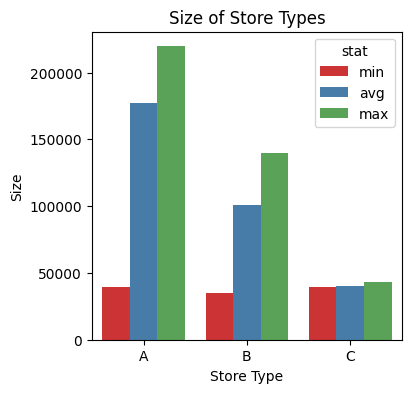

In [20]:
# Checking min, max, average store size by Type
stdf = stores.groupby('Type').agg({
    'Size': ['min', 'mean', 'max']
}).reset_index()
stdf.columns = ['Type', 'min', 'avg', 'max']
stdf['avg'] = round(stdf['avg'], 2)

# Reshape for plotting
m_df = pd.melt(stdf, id_vars="Type", var_name="stat", value_name="Size")
fig, ax = plt.subplots(figsize=(4,4))
sns.barplot(x='Type', y='Size', hue='stat', data=m_df, ax=ax, palette='Set1').set_title('Size of Store Types')
plt.xlabel('Store Type')
plt.show()

#### Observations
- Type 'A' are the biggest store types with highest 'max' and 'average'  
- Type 'C' are the smallest stores with lowest 'max' and 'average'    
- Type 'B' average store size is in the middle  
- But the Minimun store size is close for all the store types  

#### Sales Data

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


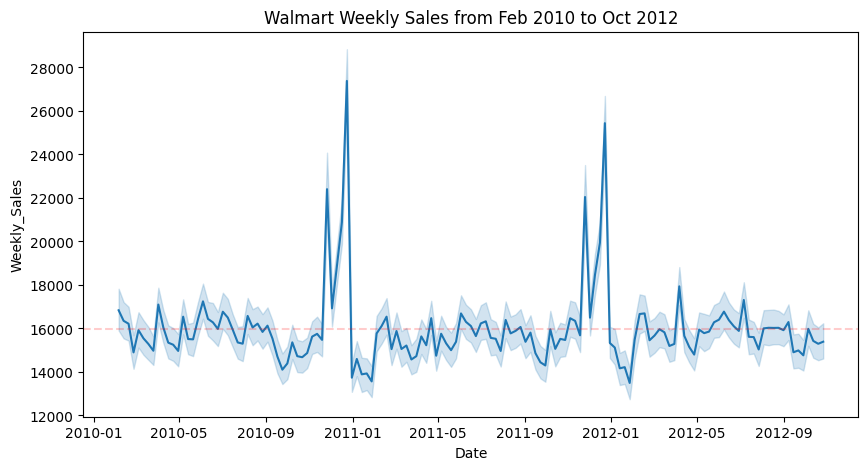

In [21]:
plt.figure(figsize=(10,5))
sns.lineplot(data=pdf, 
             x='Date', 
             y='Weekly_Sales',
            ).set_title('Walmart Weekly Sales from Feb 2010 to Oct 2012')
plt.axhline(pdf['Weekly_Sales'].mean(), color='r', alpha=0.2, linestyle='--')
plt.show()

#### Observations
- We see a spike in Sales during the holiday season (November to December) every year  
- The spike was highest on 2011  
- Average sales moves around 16000$ for the rest of the Months  

#### Taking a closer look at the Spike

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


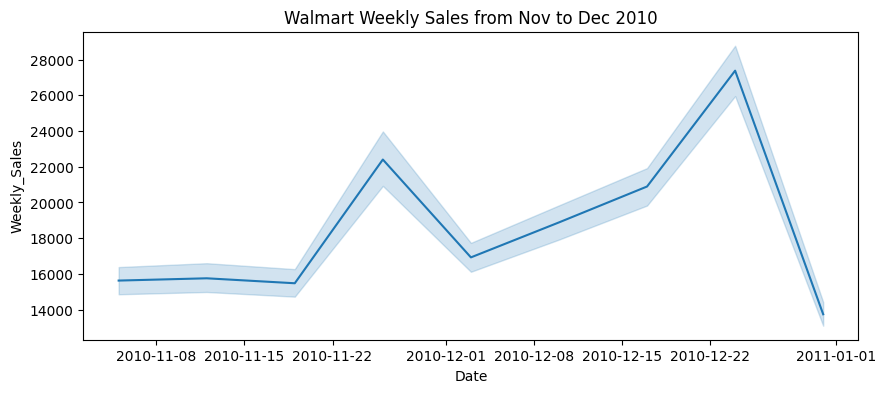

In [22]:
plt.figure(figsize=(10,4))
sns.lineplot(
    data=pdf.loc[(pdf.index >'2010-11-01') & (pdf.index<'2011-01-01')], 
    x='Date', y='Weekly_Sales'
    ).set_title('Walmart Weekly Sales from Nov to Dec 2010')
plt.show()

**The spike is seen during ThanksGiving (23-Nov) Black Friday(24-Nov) and Christmas (25-Dec)**

### Analyzing Sales by Month, Quarter, Year

In [23]:
pdf['Day'] = pdf.index.day
pdf['Month'] = pdf.index.month
pdf['Quarter'] = pdf.index.quarter
pdf['Year'] = pdf.index.year

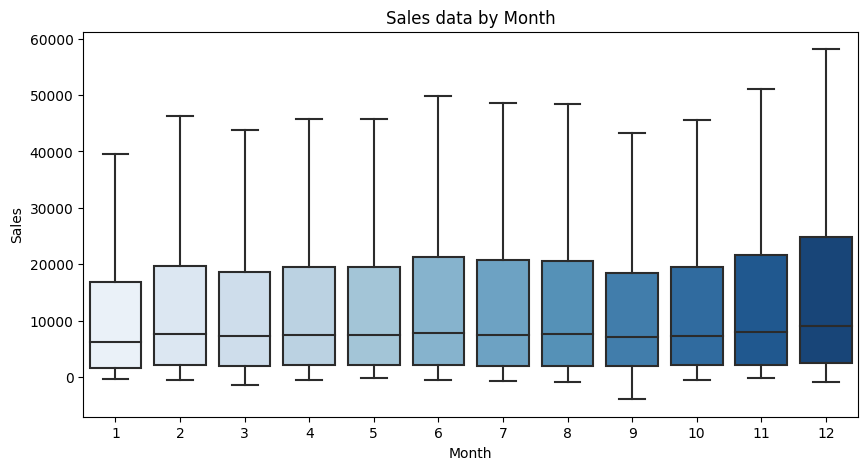

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(data=pdf.loc[(pdf.index >'2011-01-01') & (pdf.index<'2011-12-31')], x='Month', y='Weekly_Sales', 
            palette='Blues', showfliers=False
           ).set_title('Sales data by Month')
plt.ylabel('Sales')
plt.show()

- We can see the increase in sales in Nov(11) and December(12)  
- June(6) also has slightly higher sales  
- January(1) sales are lowest, it can be due to people avoiding shopping just after the holiday season  

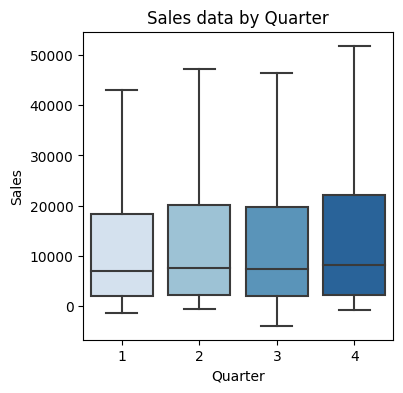

In [25]:
plt.figure(figsize=(4,4))
sns.boxplot(data=pdf.loc[(pdf.index >'2011-01-01') & (pdf.index<'2011-12-31')], x='Quarter', y='Weekly_Sales', 
            palette='Blues', showfliers=False
           ).set_title('Sales data by Quarter')
plt.ylabel('Sales')
plt.show()

**Q4 has the highest sales due to holiday season**

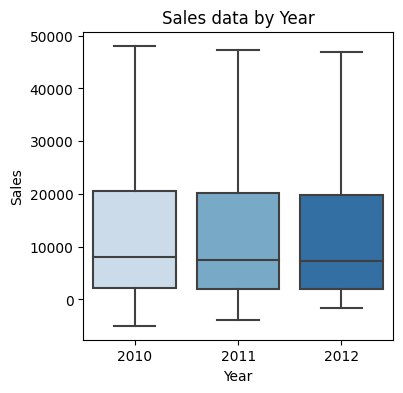

In [26]:
plt.figure(figsize=(4,4))
sns.boxplot(data=pdf, x='Year', y='Weekly_Sales', 
            palette='Blues', showfliers=False
           ).set_title('Sales data by Year')
plt.ylabel('Sales')
plt.show()

**We see a decrease in Sales from 2010 to 2012, It can happen due to the following reasons:**  
- We dont have sales of Nov and Dec in 2012  
- We also dont have sales of Jan in 2010 (which might make the avg a little higher than 2011)  

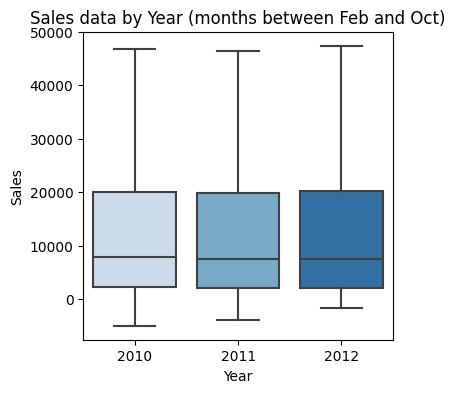

In [27]:
plt.figure(figsize=(4,4))
sns.boxplot(data=pdf.loc[pdf.index.month.isin([2,3,4,5,6,7,8,9,10])], x='Year', y='Weekly_Sales', 
            palette='Blues', showfliers=False
           ).set_title('Sales data by Year (months between Feb and Oct)')
plt.ylabel('Sales')
plt.show()


**Taking data of Months Feb-Oct as they are available for all years**  
- We can see the sales is not decreasing over the years

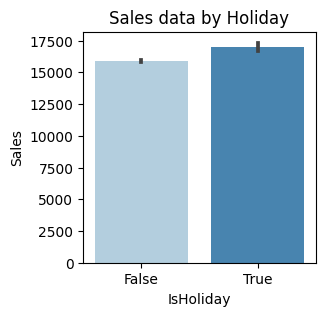

In [28]:
plt.figure(figsize=(3,3))
sns.barplot(data=pdf, x='IsHoliday', y='Weekly_Sales', 
            palette='Blues', #showfliers=False
           ).set_title('Sales data by Holiday')
plt.ylabel('Sales')
plt.show()

**Sales are slightly higher during Holidays**

### Analyzing Store Types with Sales

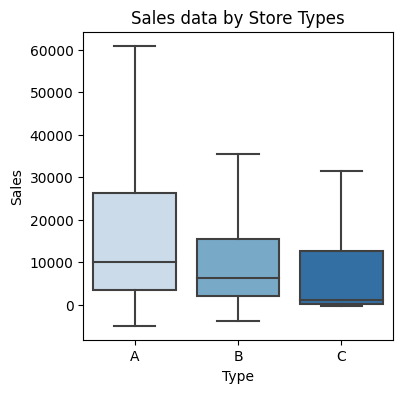

In [29]:
plt.figure(figsize=(4,4))
sns.boxplot(data=pdf, x='Type', y='Weekly_Sales', 
            palette='Blues' , showfliers=False
           ).set_title('Sales data by Store Types')
plt.ylabel('Sales')
plt.show()

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pan

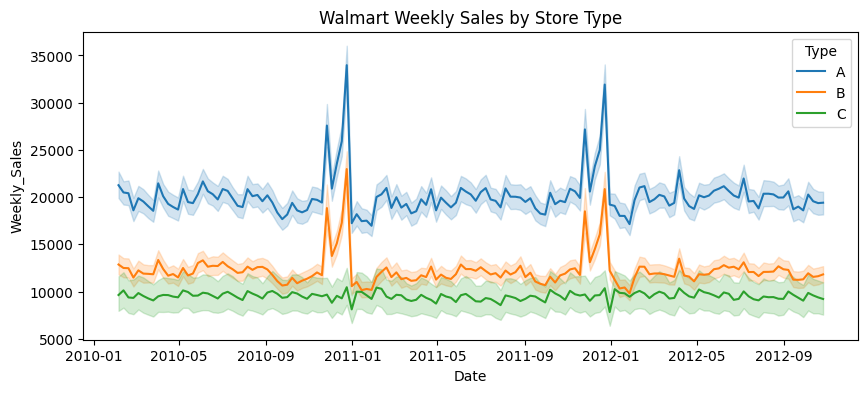

In [30]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='Date', 
             y='Weekly_Sales',
             hue='Type'
            ).set_title('Walmart Weekly Sales by Store Type')
plt.show()

**Bigger stores (A) have higher sales compared to smaller stores (B)**

### Analyzing additional Features with Sales

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pan

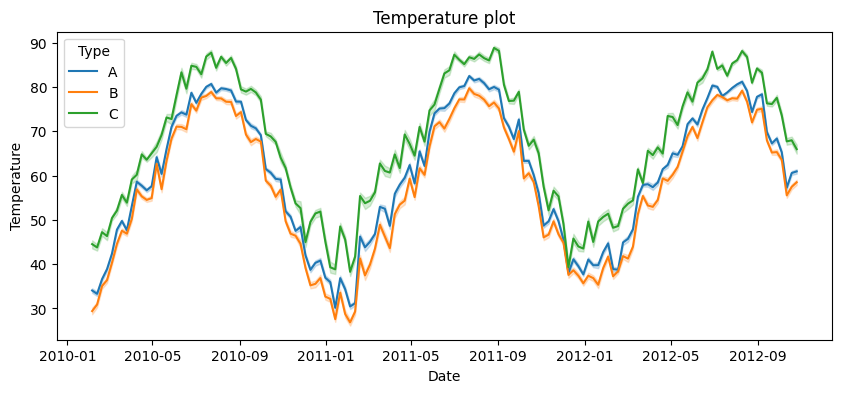

In [31]:
fig, ax = plt.subplots(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='Date', 
             y='Temperature',
             hue='Type',
             ax=ax,
            ).set_title('Temperature plot')
plt.show()

- Temperature around Type C stores (small stores) is high compared to other stores

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


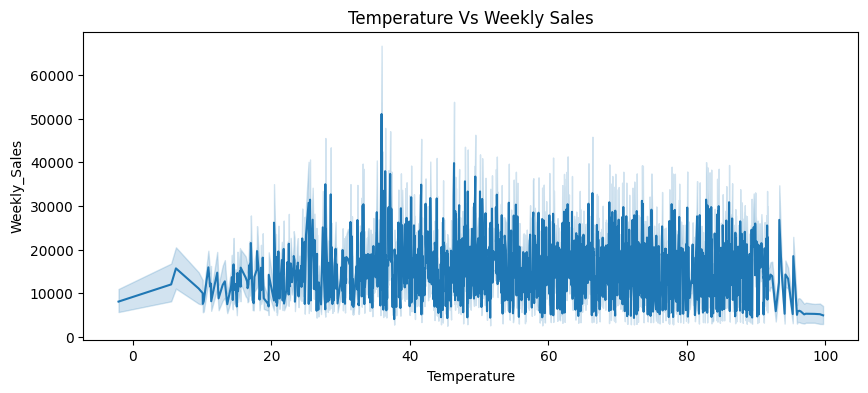

In [32]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf.loc[(pdf.index >'2011-01-01') & (pdf.index<'2011-12-31')], 
             x='Temperature', 
             y='Weekly_Sales',
            ).set_title('Temperature Vs Weekly Sales')
plt.show()

**There is no effect of Temperature on Sales**

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pan

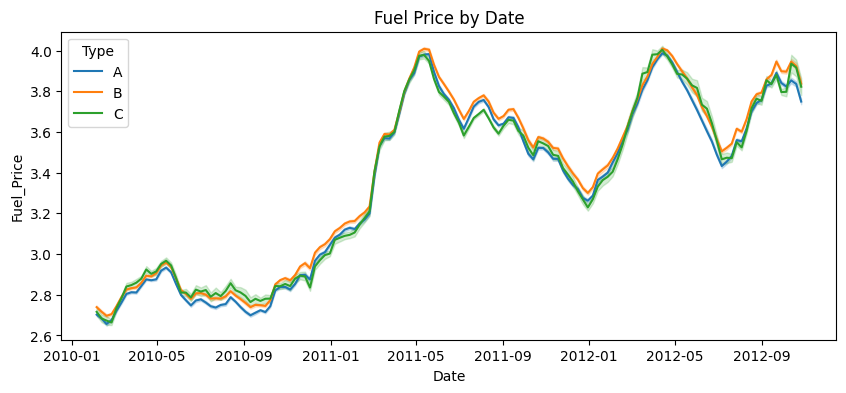

In [33]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='Date', 
             y='Fuel_Price',
             hue='Type',
            ).set_title('Fuel Price by Date')
plt.show()

**Fuel price is identical for all store types**

In [34]:
pdf['Fuel_Price_Change'] = pdf['Fuel_Price'].rolling(window=2).apply(lambda x: x.iloc[1] - x.iloc[0]).fillna(0)

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


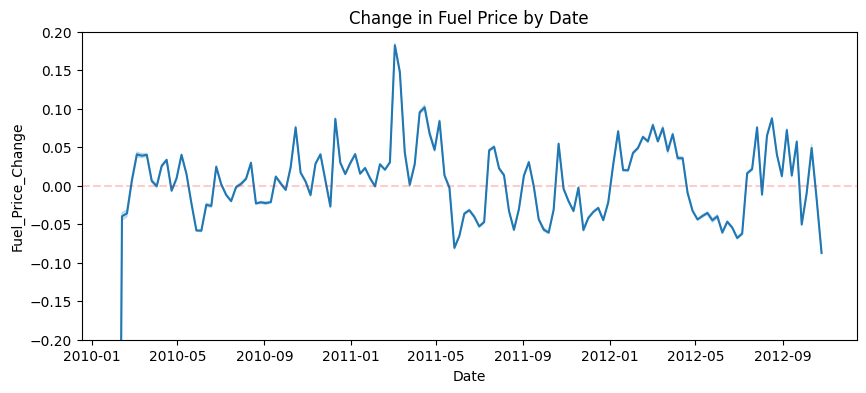

In [35]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='Date', 
             y='Fuel_Price_Change',
             #hue='Type',
            ).set_title('Change in Fuel Price by Date')
plt.axhline(pdf['Fuel_Price_Change'].mean(), color='r', alpha=0.2, linestyle='--')
plt.ylim(-0.2, 0.2)
plt.show()

**The shift (Change) in fuel price moves around randomly with the mean of 0**

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


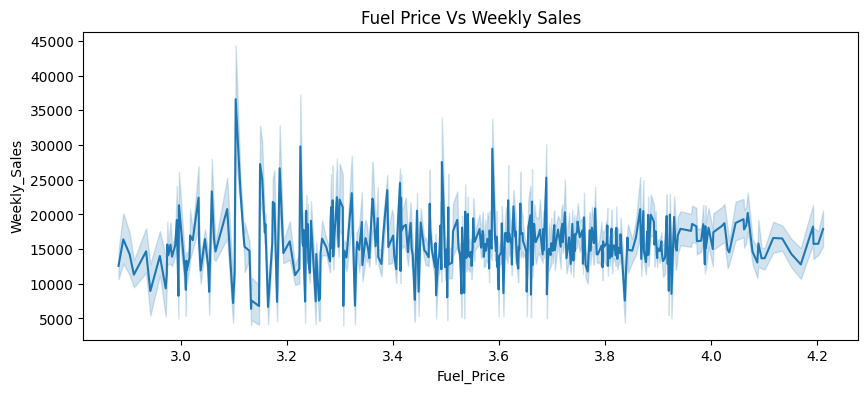

In [36]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf.loc[(pdf.index >'2011-01-01') & (pdf.index<'2011-12-31')], 
             x='Fuel_Price', 
             y='Weekly_Sales',
            ).set_title('Fuel Price Vs Weekly Sales')
plt.show()

**There is no effect of Fuel Price of the region on Sales**

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pan

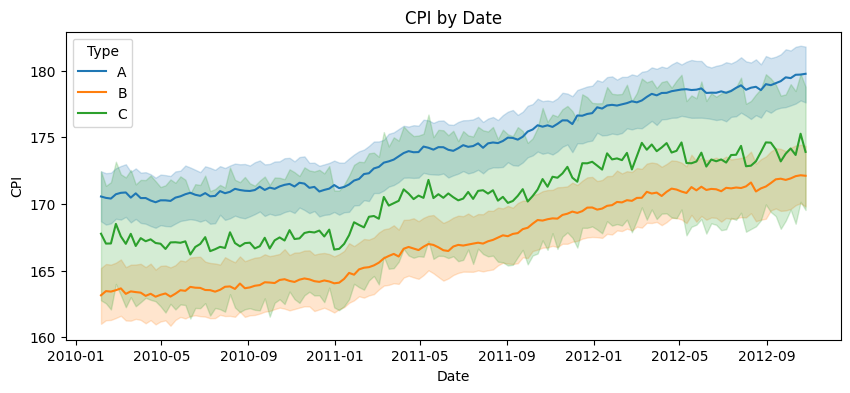

In [37]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='Date', 
             y='CPI',
             hue='Type'
            ).set_title('CPI by Date')
plt.show()

- Overall CPI (Consumer Price Index) is increase over time  
- Type A stores have highest CPI index  
- Type C stores have higher CPI index than Type B stores  

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


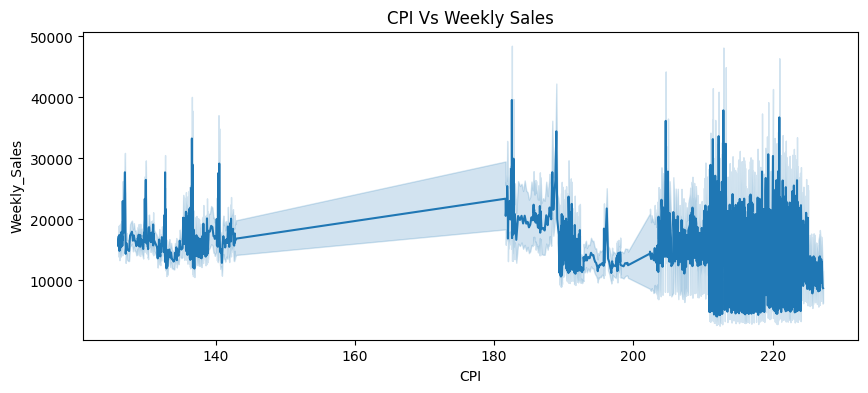

In [38]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='CPI', 
             y='Weekly_Sales',
            ).set_title('CPI Vs Weekly Sales')
plt.show()

**There is no effect of CPI (Consumer Price Index) on sales**

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pan

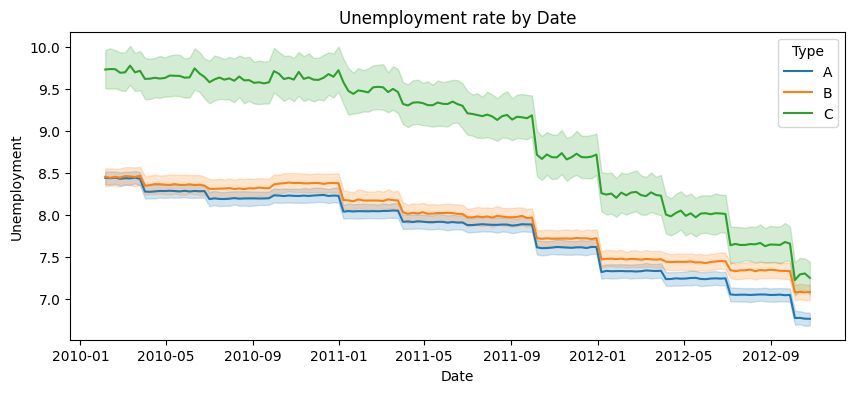

In [39]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='Date', 
             y='Unemployment',
             hue='Type',
            ).set_title('Unemployment rate by Date')
plt.show()

- Unemployment Rate is descending over time
- Unemployment Rate is highest around Type C stores (small stores), they could be around rural areas
- Unemployment is similar around Type A and B stores

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


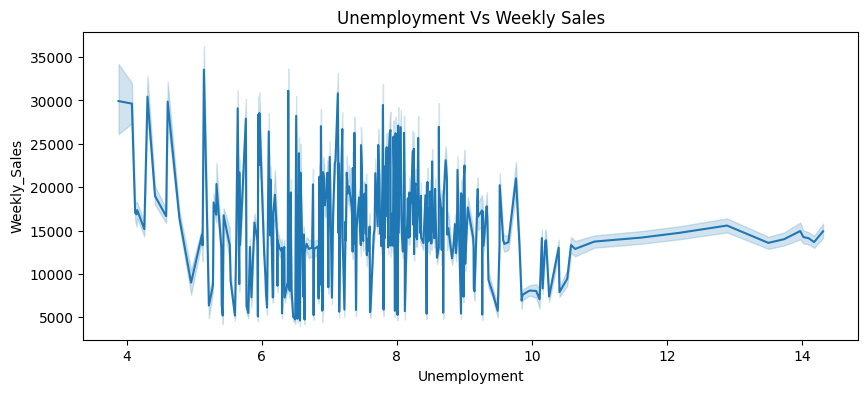

In [40]:
plt.figure(figsize=(10,4))
sns.lineplot(data=pdf, 
             x='Unemployment', 
             y='Weekly_Sales',
            ).set_title('Unemployment Vs Weekly Sales')
plt.show()

**There is no effect of Unemployment on sales**

## Outlier Analysis

- There are several ways to treat outliers in a dataset, depending on the nature of the outliers and the problem being solved.  
- We will use **Capping** Technique to handle outliers.  
- First We will visualize the distribution of the data
- Then we will decide the values for capping

c:\Python311\Lib\site-packages\seaborn\categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


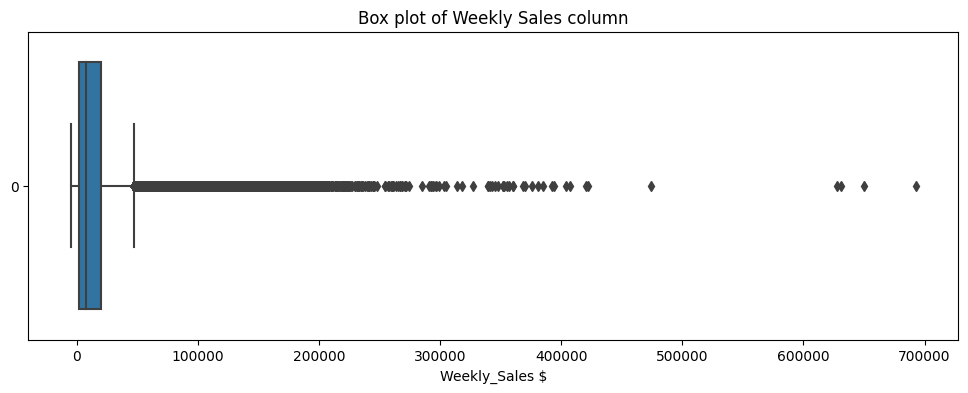

In [41]:
plt.figure(figsize=(12,4))
sns.boxplot(pdf['Weekly_Sales'], orient='h')
plt.xlabel('Weekly_Sales $')
plt.title('Box plot of Weekly Sales column')
plt.show()

The data has large gaps after 200000

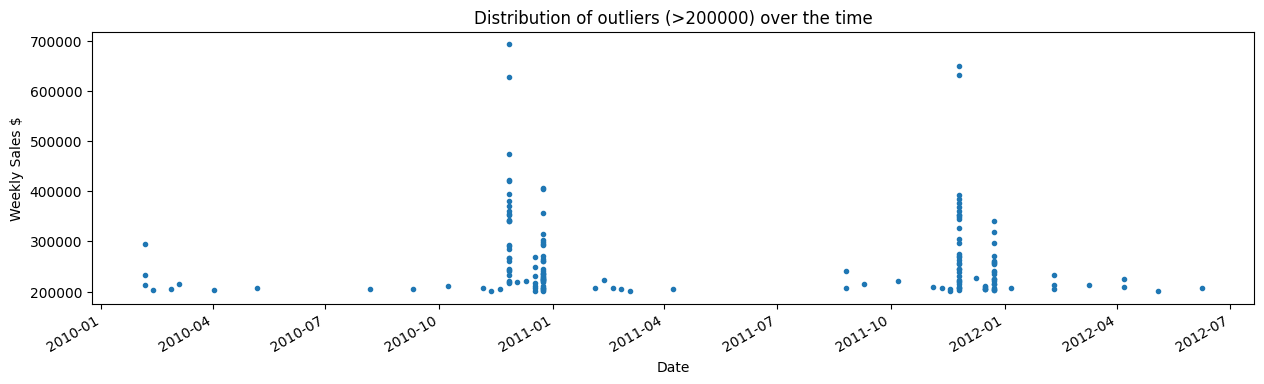

In [42]:
pdf.query('Weekly_Sales > 200000')['Weekly_Sales'].plot(figsize=(15,4), style='.')
plt.ylabel('Weekly Sales $')
plt.title('Distribution of outliers (>200000) over the time')
plt.show()

Throughout the year, we have some positive outliers (sales more than 200000 $)
  
Now looking at Negative values

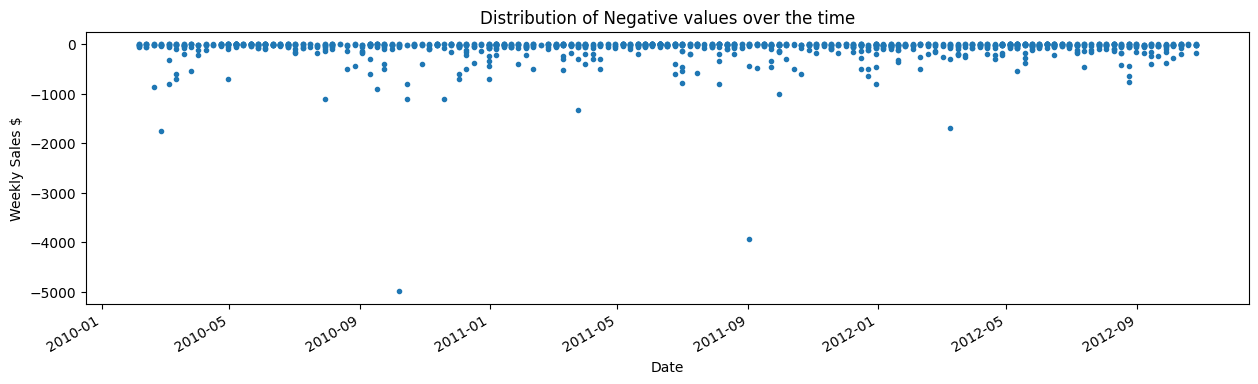

In [43]:
pdf.query('Weekly_Sales < 0')['Weekly_Sales'].plot(figsize=(15,4), style='.')
plt.ylabel('Weekly Sales $')
plt.title('Distribution of Negative values over the time')
plt.show()

**We will remove these outliers before trainig the model**

In [44]:
old_count = pdf.shape[0]
print('Dataset_size before removing outliers: ', old_count)
pdf = pdf.query('Weekly_Sales >= 0 and Weekly_Sales < 200000')
new_count = pdf.shape[0]
print('Dataset_size after removing outliers: ', pdf.shape[0])
print('Percent decrease in data: ', round((old_count - new_count)*100/old_count,2))

Dataset_size before removing outliers:  421570
Dataset_size after removing outliers:  420122
Percent decrease in data:  0.34


Only 0.34 % of the data was removed

## Correlation Matrix

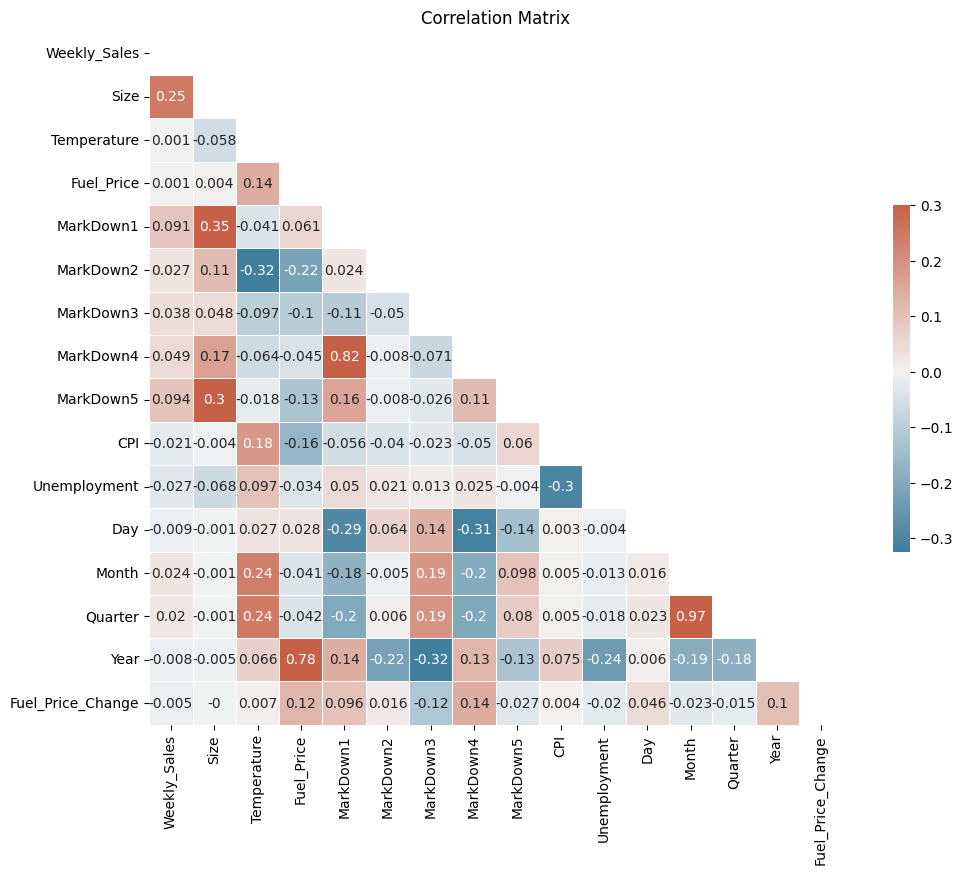

In [45]:
# Numerical cols
num_cols = [x for x in pdf.columns if x not in ['Type','IsHoliday','Dept','Store']]

# Compute the correlation matrix
corr = pdf[num_cols].corr().round(3)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(13, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, annot=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix')
plt.show()

- MarkDown4 and MarkDown1 have high correlation  
- MarkDown1 and MarkDown5 have positive correlation with Size  
    - They could be exclusive offers for bigger stores  
- MarkDown2 have negative correlation with Temperature  
    - MarkDown2 could be offers during winters / holiday offers  

## Pre Processing Data

## Joining Datasets and Creating features

In [46]:
# Load CSVs using pandas (no Spark)
df = pd.read_csv('../kaggle/input/train.csv')
stores = pd.read_csv('../kaggle/input/stores.csv')
features = pd.read_csv('../kaggle/input/features.csv')
# Converting 'NA' strings in MarkDown columns to null values
for i in range(1, 6):
    col_name = f'MarkDown{i}'
    features[col_name] = pd.to_numeric(features[col_name], errors='coerce')
pdf = pd.merge(df, stores, on='Store', how='inner')
pdf = pd.merge(pdf, features.drop('IsHoliday', axis=1), on=['Date', 'Store'], how='left')
pdf['Date'] = pd.to_datetime(pdf['Date'])
pdf.set_index('Date', inplace=True)
pdf["CPI"] = pd.to_numeric(pdf["CPI"], downcast="float")
pdf["Unemployment"] = pd.to_numeric(pdf["Unemployment"], downcast="float")
pdf['Day'] = pdf.index.day
pdf['Week'] = np.ceil(pdf.index.dayofyear/7).astype(int)
pdf['Month'] = pdf.index.month
pdf['Quarter'] = pdf.index.quarter
pdf['Year'] = pdf.index.year
pdf = pdf.query('Weekly_Sales >= 0 and Weekly_Sales < 200000')


## Handling Missing values

In [47]:
pdf.isnull().sum()

Store                0
Dept                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       269992
MarkDown2       309270
MarkDown3       283525
MarkDown4       285656
MarkDown5       269244
CPI                  0
Unemployment         0
Day                  0
Week                 0
Month                0
Quarter              0
Year                 0
dtype: int64

- **Only MarkDown columns have missing values.**  
- As they are anonimized offer related sales. We can assume if there is no data (NaN) for a particular day then the value is 0.  
- So we can replace nulls with 0.  

In [48]:
pdf.fillna(0, inplace=True)

## Converting String / Boolean Columns into Numerical

Converting **"Is Holiday"** column to int  
Changing the type will replace True -> 1 and False -> 0  

In [49]:
# Converting Is Holiday column to int
# Changing the type will replace True -> 1 and False -> 0
pdf['IsHoliday'] = pdf['IsHoliday'].astype('int')

Converting **Type of store** into numerical  
We will use the order of size to decide the numerical values for store types  
As we have seen Type **A stores are largest and C are smallest**,   
we will use the following mapping  
**C-> 0, B-> 1, A-> 2**

In [50]:
# Converting Type of store into numerical
# We will use the order of size to decide the numerical values for store types
# As we have seen Type A stores are largest and C are smallest, 
# we will use the following mapping
# C-> 0, B-> 1, A-> 2

pdf['Type'] = pdf['Type'].replace({'C': 0, 'B': 1, 'A': 2})

C:\Users\shazi\AppData\Local\Temp\ipykernel_15636\1090588490.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pdf['Type'] = pdf['Type'].replace({'C': 0, 'B': 1, 'A': 2})


## XGBoost Model

In [51]:
TARGET = ['Weekly_Sales']
FEATURES = [i for i in pdf.columns if i not in TARGET]

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(pdf[FEATURES], pdf[TARGET],
                                                   test_size=0.2, random_state=130)

In [53]:
import xgboost as xgb
reg = xgb.XGBRegressor(n_estimators=2000, early_stopping_rounds=50,
                      learning_rate=0.5)
model = reg.fit(X_train, y_train,
       eval_set=[(X_train, y_train), (X_test, y_test)],
       verbose=100)

[0]	validation_0-rmse:15063.79170	validation_1-rmse:15139.93328
[100]	validation_0-rmse:4242.24583	validation_1-rmse:4492.70623
[200]	validation_0-rmse:3482.17459	validation_1-rmse:3878.64994
[300]	validation_0-rmse:3087.08542	validation_1-rmse:3587.85615
[400]	validation_0-rmse:2811.11912	validation_1-rmse:3408.92916
[500]	validation_0-rmse:2608.76790	validation_1-rmse:3287.69013
[600]	validation_0-rmse:2453.39392	validation_1-rmse:3205.62576
[700]	validation_0-rmse:2334.43202	validation_1-rmse:3135.30009
[800]	validation_0-rmse:2237.46742	validation_1-rmse:3089.50207
[900]	validation_0-rmse:2146.26464	validation_1-rmse:3049.58338
[1000]	validation_0-rmse:2069.41808	validation_1-rmse:3019.87896
[1100]	validation_0-rmse:2000.64612	validation_1-rmse:2989.92329
[1200]	validation_0-rmse:1937.12835	validation_1-rmse:2962.81252
[1300]	validation_0-rmse:1882.34812	validation_1-rmse:2942.05732
[1400]	validation_0-rmse:1837.24162	validation_1-rmse:2926.77431
[1500]	validation_0-rmse:1783.89858

In [54]:
y_pred = reg.predict(X_test)

In [ ]:
xgboost_accuracy = reg.score(X_test,y_test)*100
print("XGB Regressor Evaluation Metrics: ")
print("Accuracy", round(xgboost_accuracy,3))
print("MAE \t" , round(metrics.mean_absolute_error(y_test, y_pred),3))
print("MSE \t" , round(metrics.mean_squared_error(y_test, y_pred),3))
print("RMSE \t" , round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)),3))
print("R2 \t" , round(metrics.explained_variance_score(y_test, y_pred),5))

XGB Regressor Evaluation Metrics: 
Accuracy 98.348
MAE 	 1570.744
MSE 	 8134464.931
RMSE 	 2852.098
R2 	 0.98348


In [58]:
print('Top 10 features with their Feature importance scores: ')
pd.DataFrame(data=reg.feature_importances_,
            index=reg.feature_names_in_,
            columns=['Feature Importance']).sort_values('Feature Importance', ascending=False).head(10)

Top 10 features with their Feature importance scores: 


,Feature Importance
Size,0.349576
Dept,0.214630
Type,0.146933
Store,0.098718
CPI,0.038189
Week,0.030618
IsHoliday,0.024891
Month,0.023361
Year,0.019829
Unemployment,0.011220


c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf

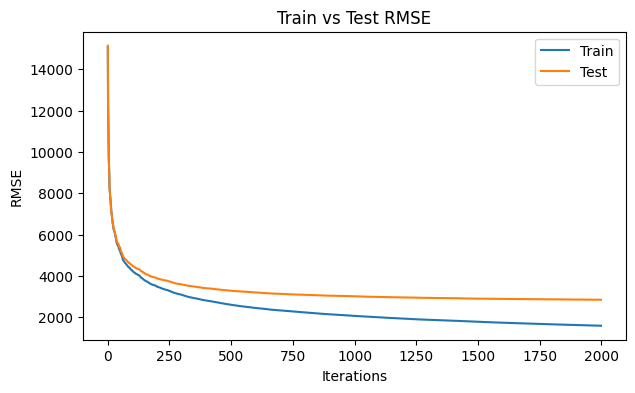

In [59]:
fig, ax = plt.subplots(1,1,figsize=(7,4))
score_hist = pd.DataFrame({'Train_rmse':model.evals_result()['validation_0']['rmse'], 'Test_rmse':model.evals_result()['validation_1']['rmse']})
sns.lineplot(score_hist['Train_rmse'], ax=ax, label='Train')
sns.lineplot(score_hist['Test_rmse'], ax=ax, label='Test')
plt.ylabel('RMSE')
plt.xlabel('Iterations')
plt.title('Train vs Test RMSE')
plt.show()

In [60]:
val = pdf.loc[pdf.index >= '2012-05-01']
X_val, y_val = val[FEATURES], val[TARGET]
val['prediction'] = reg.predict(X_val)

C:\Users\shazi\AppData\Local\Temp\ipykernel_15636\2158810898.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['prediction'] = reg.predict(X_val)


c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf

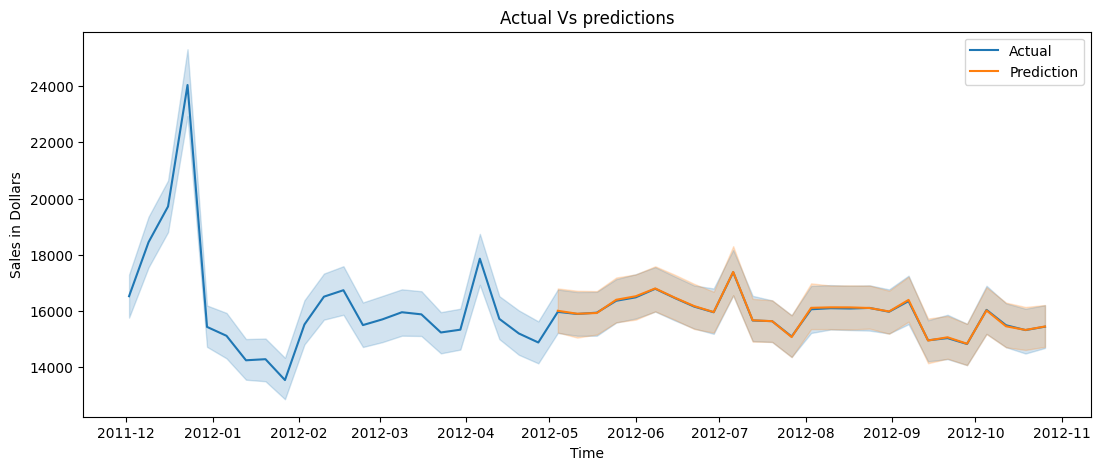

In [61]:
fig, ax = plt.subplots(1,1,figsize=(13,5))
sns.lineplot(pdf['Weekly_Sales'].loc[pdf.index>'2011-12-01'], ax=ax, label='Actual')
sns.lineplot(val['prediction'], ax=ax, label='Prediction')
plt.ylabel('Sales in Dollars')
plt.xlabel('Time')
plt.title('Actual Vs predictions')
plt.show()

The Predictions are pretty close to the actual values as we have a **accuracy of 98%**

c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


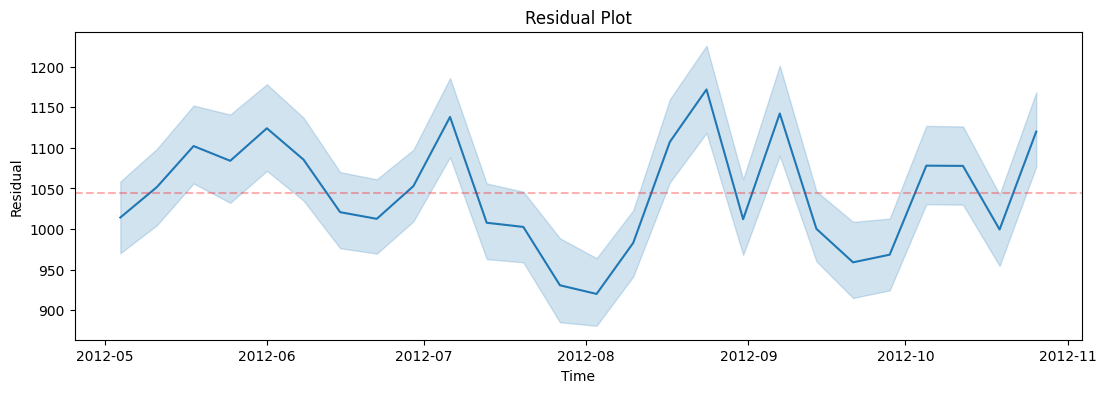

In [62]:
val = val.assign(Residual= abs(val['Weekly_Sales'] - val['prediction']))
fig, ax = plt.subplots(1,1,figsize=(13,4))
#sns.lineplot(pdf['Weekly_Sales'].loc[pdf.index>'2011-12-01'], ax=ax, label='Actual')
sns.lineplot(val['Residual'], ax=ax)
plt.axhline(val['Residual'].mean(), linestyle='--', color='r', alpha=0.3)
#plt.ylabel('Sales in Dollars')
plt.xlabel('Time')
plt.title('Residual Plot')
plt.show()

The residuals are close to the MAE

## Predicting Overall sales per day using SARIMA Model

#### Preparing Dataset (cumulating sales for all stores)

In [64]:
cum_pdf = pdf['Weekly_Sales'].groupby('Date').sum().to_frame(name='Weekly_Sales')

In [65]:
train = cum_pdf.loc[cum_pdf.index < '2012-05-01']
test = cum_pdf.loc[cum_pdf.index >= '2012-05-01']

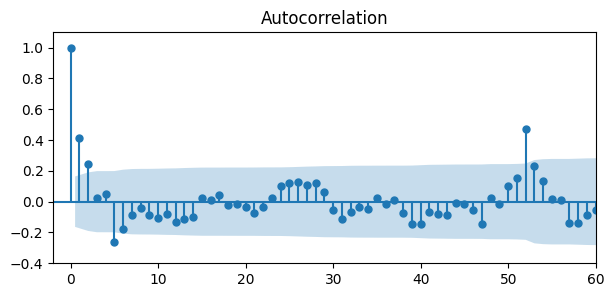

In [66]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(figsize=(7,3))
acf_plot = plot_acf(cum_pdf.Weekly_Sales, lags=100, ax=ax)
plt.ylim(-0.4, 1.1)
plt.xlim(-2,60)
plt.show()

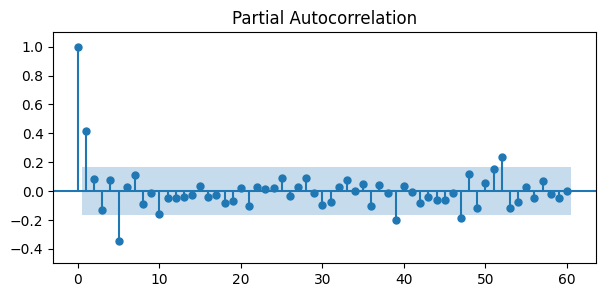

In [67]:
fig, ax = plt.subplots(figsize=(7,3))
pacf_plot = plot_pacf(cum_pdf.Weekly_Sales, lags=60, ax=ax)
plt.ylim(-0.5, 1.1)
plt.show()

**Based on PACF, we should start with Auto Regressive(AR) model with lags 1,2,5,52**

### AD-Fuller Test

In [68]:
from statsmodels.tsa.stattools import adfuller
ADF_result = adfuller(cum_pdf.Weekly_Sales)   
print(f'ADF Statistic: {ADF_result[0]}') 
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -6.357042012534242
p-value: 2.5278147982296737e-08


As the p-value is less than 0.05 and ADF statistic is a negative number  
**The Time series is Stationary**

In [69]:
import statsmodels.api as sm
order_aic_bic =[]

# Loop over p values from 0-2
for p in [1,2,5,52]:
    # Loop over q values from 0-2
    for q in [1,2,5,52]:
      
        try:
            # create and fit ARMA(p,q) model
            model = sm.tsa.statespace.SARIMAX(train.Weekly_Sales, order=(p, 0, q))
            results = model.fit(maxiter=100, full_output=False, disp=False)
            
            # Print order and results
            order_aic_bic.append((p, q, results.aic, results.bic))            
        except:
            print(p, q, None, None)
            
# Make DataFrame of model order and AIC/BIC scores
order_df = pd.DataFrame(order_aic_bic, columns=['p', 'q', 'aic','bic'])

c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Python311\Li

In [70]:
# lets sort them by AIC and BIC

# Sort by AIC
print("Sorting SARIMA model with different (p,q) by AIC ")
print("\n")
print(order_df.sort_values('aic').reset_index(drop=True))

# Sort by BIC
print("Sorted by BIC ")
print("\n")
print(order_df.sort_values('bic').reset_index(drop=True))

Sorting SARIMA model with different (p,q) by AIC 


     p   q          aic          bic
0    2   5    16.000000    38.097391
1   52   5  3879.103009  4039.309097
2   52   1  3882.436349  4031.593742
3   52   2  3882.506140  4034.425707
4    1   5  3920.531867  3939.867085
5    5   5  3925.498751  3955.882664
6    2   1  3930.915414  3941.964110
7    1   2  3937.795438  3948.844134
8    5   2  3939.889030  3961.986422
9    5   1  3942.014748  3961.349966
10   1   1  3942.865561  3951.152083
11   2   2  3945.281683  3959.092553
12   1  52  3981.632427  4130.789819
13   2  52  3982.751904  4134.671471
14   5  52  4001.086182  4161.292270
15  52  52  4060.920711  4350.948974
Sorted by BIC 


     p   q          aic          bic
0    2   5    16.000000    38.097391
1    1   5  3920.531867  3939.867085
2    2   1  3930.915414  3941.964110
3    1   2  3937.795438  3948.844134
4    1   1  3942.865561  3951.152083
5    5   5  3925.498751  3955.882664
6    2   2  3945.281683  3959.092553
7    5

p = 1 and q = 5 gives the lowest BIC &  
p = 52 and q = 5 gives the lowest AIC

In [71]:
# The model with the best p and q found from pervious step
import statsmodels.api as sm
model = sm.tsa.statespace.SARIMAX(train.Weekly_Sales, order=(52, 0, 5))
# Fit model
results = model.fit()
# Assign residuals to variable
residuals = results.resid

c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [72]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           Weekly_Sales   No. Observations:                  117
Model:              SARIMAX(52, 0, 5)   Log Likelihood               -1888.228
Date:                Wed, 21 May 2025   AIC                           3892.457
Time:                        00:12:22   BIC                           4052.663
Sample:                    02-05-2010   HQIC                          3957.498
                         - 04-27-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0094      0.113      0.083      0.934      -0.213       0.232
ar.L2          0.0343      0.104      0.329      0.742      -0.170       0.239
ar.L3         -0.0223      0.103     -0.217      0.828      -0.224       0.179
ar.L4         -0.0243      0.112     -0.218      0.827      -0.243       0.194
ar.L5         -0.0186      0.067     -0.277      0.782      -0.151       0.113
ar.L6         -0.0914      0.078     -1.164      0.244      -0.245       0.062
ar.L7          0.0895      0.079      1.137      0.256      -0.065       0.244
ar.L8         -0.0354      0.095     -0.372      0.710      -0.222       0.152
ar.L9         -0.0665      0.089     -0.751      0.452      -0.240       0.107
ar.L10         0.0424      0.080      0.530      0.596      -0.114       0.199
ar.L11        -0.0526      0.072     -0.726      0.468      -0.195       0.089
ar.L12         0.0868      0.088      0.983      0.326      -0.086       0.260
ar.L13        -0.0084      0.075     -0.112      0.911      -0.156       0.139
ar.L14        -0.1019      0.088     -1.160      0.246      -0.274       0.070
ar.L15         0.1068      0.072      1.480      0.139      -0.035       0.248
ar.L16         0.0333      0.074      0.448      0.654      -0.112       0.179
ar.L17         0.0276      0.076      0.365      0.715      -0.120       0.176
ar.L18         0.0065      0.058      0.113      0.910      -0.107       0.120
ar.L19        -0.0275      0.083     -0.330      0.741      -0.191       0.136
ar.L20         0.0446      0.088      0.505      0.613      -0.129       0.218
ar.L21        -0.0336      0.101     -0.333      0.739      -0.231       0.164
ar.L22        -0.0095      0.098     -0.097      0.923      -0.201       0.182
ar.L23         0.0226      0.100      0.225      0.822      -0.174       0.219
ar.L24         0.0118      0.126      0.094      0.925      -0.234       0.258
ar.L25         0.0770      0.117      0.655      0.512      -0.153       0.307
ar.L26        -0.0115      0.086     -0.134      0.893      -0.179       0.156
ar.L27        -0.0140      0.120     -0.117      0.907      -0.249       0.221
ar.L28         0.0689      0.100      0.691      0.490      -0.127       0.264
ar.L29         0.0136      0.110      0.124      0.901      -0.201       0.229
ar.L30         0.0148      0.100      0.148      0.882      -0.182       0.211
ar.L31        -0.0114      0.079     -0.144      0.886      -0.166       0.144
ar.L32         0.0138      0.103      0.134      0.894      -0.189       0.217
ar.L33         0.0857      0.099      0.866      0.386      -0.108       0.280
ar.L34        -0.0366      0.089     -0.412      0.680      -0.211       0.138
ar.L35        -0.0086      0.096     -0.089      0.929      -0.198       0.181
ar.L36        -0.0010      0.092     -0.011      0.991      -0.182       0.180
ar.L37        -0.0384      0.084     -0.454      0.650      -0.204       0.127
ar.L38         0.1333      0.107      1.250      0.211      -0.076       0.342
ar

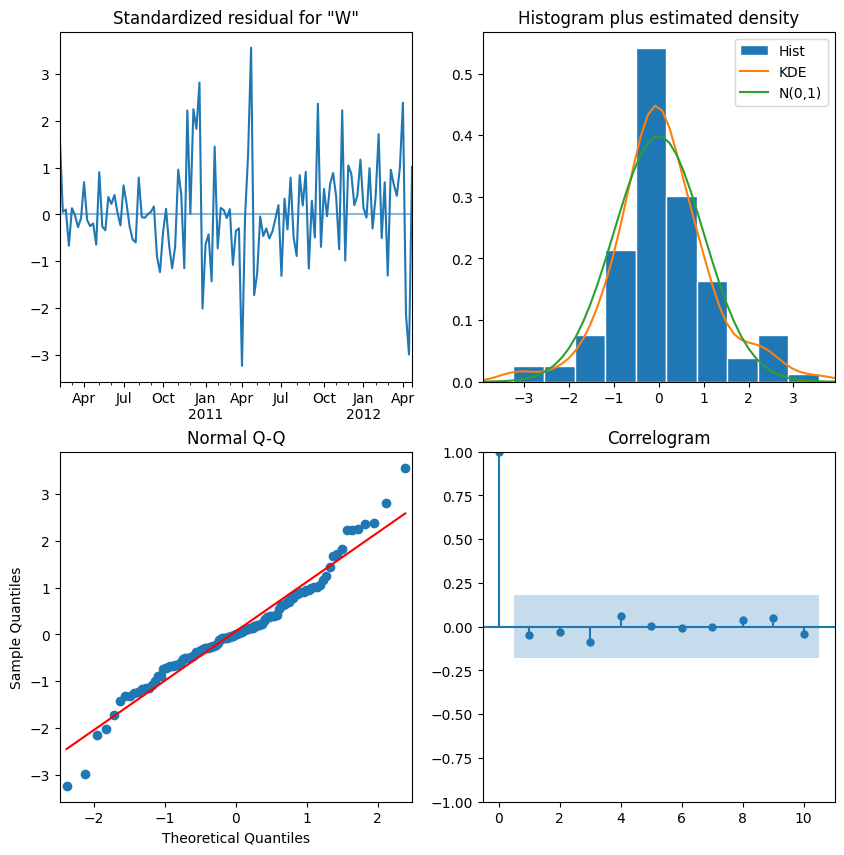

In [73]:
results.plot_diagnostics(figsize=(10,10))
plt.show()

**Standardized residuals plot:** The top left plot shows one-step-ahead standardized residuals. If our model is working correctly, there should be no obvious pattern in the residuals. This is shown here in this case.  
**Histogram plus estimated density plot:** This plot shows the distribution of the residuals. The histogram shows us the measured distribution; the orange line shows a smoothed version of this histogram, and the green line shows a normal distribution. If the model is good these two lines should be the same. Here there are little differences between them, which indicate that our model is doing great.  
**Normal Q-Q plot:** The Q-Q plot compare the distribution of the residuals to the normal distribution. If the distribution of the residuals is normal, then all the points should lie along the red line, except for some values at the end.  
**Correlogram plot:** The correlogram plot is the ACF plot of the residuals rather than the data. 95% of the correlations for lag greater than zero should not be significant (within the blue shades). If there is a significant correlation in the residuals, it means that there is information in the data that was not captured by the model.

### Predictions

In [74]:
#get the predictions and residuals
predictions = results.forecast(len(test))
predictions = pd.Series(predictions, index=test.index).to_frame(name='Weekly_Sales')
residuals = test - predictions

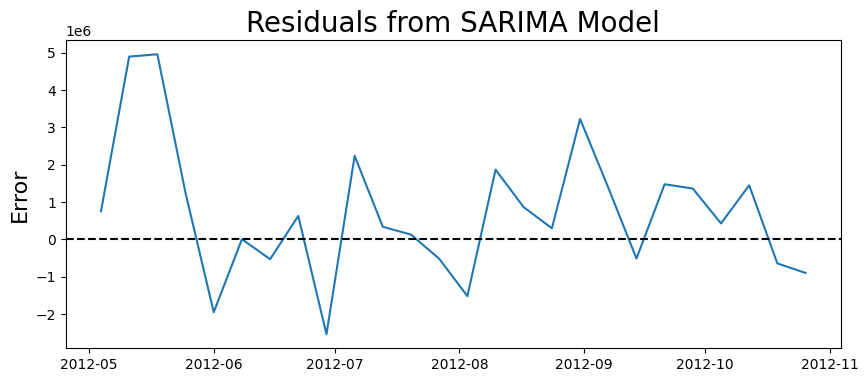

In [75]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title( 'Residuals from SARIMA Model' ,fontsize=20)
plt.ylabel( 'Error', fontsize=16)
plt.show()

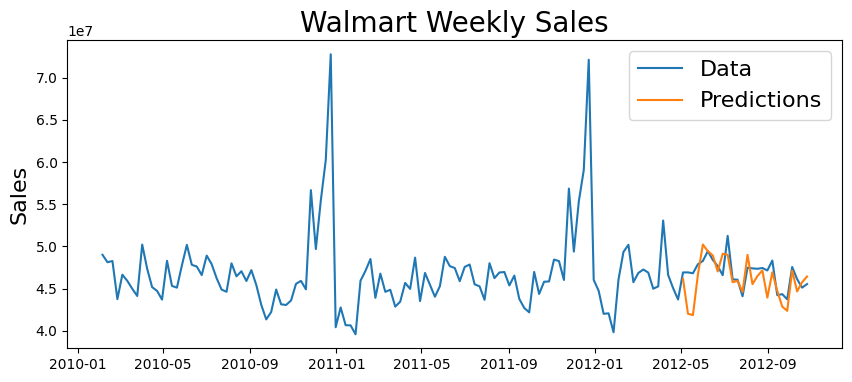

In [76]:
plt.figure(figsize=(10,4))
plt.plot(cum_pdf)
plt.plot(predictions)

plt.legend(('Data','Predictions'), fontsize=16)

plt.title('Walmart Weekly Sales', fontsize=20)
plt.ylabel('Sales', fontsize=16)
plt.show()

In [77]:
print('MAPE: ', round(np.mean(abs(residuals/test)),4))
# The mean absolute error
mae = np.mean(np.abs(residuals))
print("Mean Absolute Error: ", mae)
print('Root Mean Squared Error: ', round(np.sqrt(np.mean(residuals**2)),2))

MAPE:  0.03
Mean Absolute Error:  1409357.1132706443
Root Mean Squared Error:  1898358.39


In comparison to SARIMA model, the **XGBoost model performs much better** as it uses multidimentional data  

## LSTM Neural Network for Time Series Forecasting

1. Creating seasonal features...
2. Using 26 features for modeling
3. Scaling data with RobustScaler...
4. Creating sequences with 24 time steps...
Training data: (95, 24, 26), Testing data: (24, 24, 26)
5. Building seasonal-aware LSTM model...


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 24, 26)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 24, 32)         │         2,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 24, 256)        │       164,864 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 24, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_21                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 580,449 (2.21 MB)

 Trainable params: 579,297 (2.21 MB)

 Non-trainable params: 1,152 (4.50 KB)

6. Training model with optimized settings...
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 1.2075
Epoch 1: saving model to best_lstm_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 1.2179 - val_loss: 0.2092 - learning_rate: 0.0010
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 1.1485
Epoch 2: saving model to best_lstm_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - loss: 1.1573 - val_loss: 0.1860 - learning_rate: 0.0010
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 1.0968
Epoch 3: saving model to best_lstm_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - loss: 1.1094 - val_loss: 0.1750 - learning_rate: 0.0010
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 1.2251
Epoch 4: saving model to best_lstm_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 1.2212 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 1.0616
Epoch 5: saving model to best_l

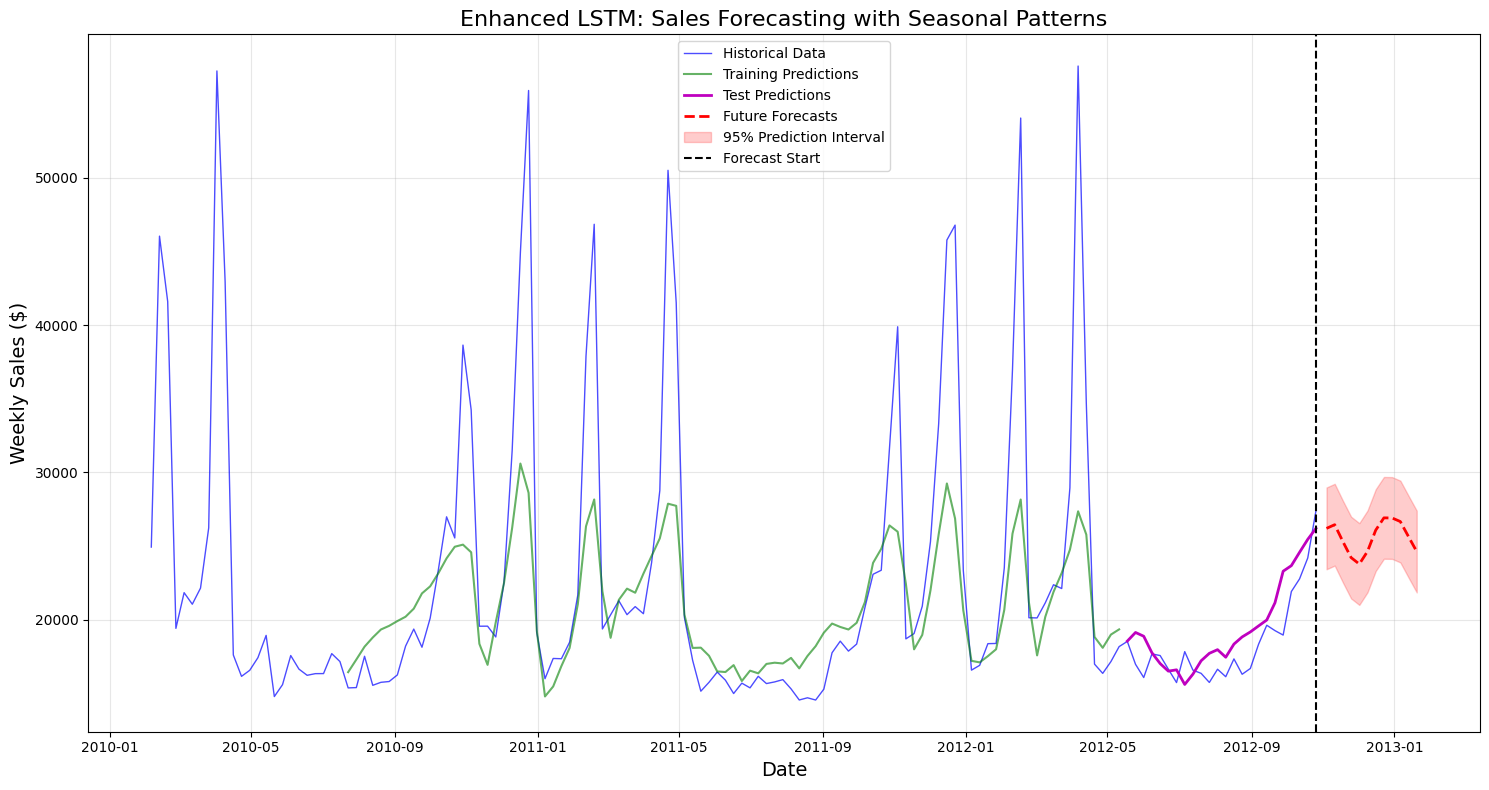

In [99]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.layers import Input, Concatenate, Lambda, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1_l2
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from datetime import timedelta

# 1. ENHANCED SEASONAL FEATURE ENGINEERING
def create_seasonal_features(df):
    """Add better seasonal and holiday features for retail sales patterns"""
    df_enhanced = df.copy()
    
    # Basic time features
    df_enhanced['Month'] = df_enhanced.index.month
    df_enhanced['Quarter'] = df_enhanced.index.quarter
    df_enhanced['Year'] = df_enhanced.index.year
    df_enhanced['WeekOfYear'] = df_enhanced.index.isocalendar().week
    df_enhanced['DayOfYear'] = df_enhanced.index.dayofyear
    
    # Better seasonal encodings with multiple frequencies
    # Monthly seasonality
    df_enhanced['Month_sin'] = np.sin(2 * np.pi * df_enhanced.index.month/12)
    df_enhanced['Month_cos'] = np.cos(2 * np.pi * df_enhanced.index.month/12)
    
    # Weekly seasonality
    df_enhanced['Week_sin'] = np.sin(2 * np.pi * df_enhanced.index.isocalendar().week/52)
    df_enhanced['Week_cos'] = np.cos(2 * np.pi * df_enhanced.index.isocalendar().week/52)
    
    # Quarterly seasonality
    df_enhanced['Quarter_sin'] = np.sin(2 * np.pi * df_enhanced.index.quarter/4)
    df_enhanced['Quarter_cos'] = np.cos(2 * np.pi * df_enhanced.index.quarter/4)
    
    # Add 52-week lag to capture yearly patterns explicitly
    df_enhanced['Sales_Lag_52'] = df_enhanced['Weekly_Sales'].shift(52).fillna(
        df_enhanced['Weekly_Sales'].mean())  # Fill with mean instead of 0
    
    # Add rolling windows of different sizes to capture various seasonality patterns
    for window in [4, 8, 12, 26, 52]:
        # Moving averages
        df_enhanced[f'Sales_MA{window}'] = df_enhanced['Weekly_Sales'].rolling(
            window=window, min_periods=1).mean()
        # Rolling standard deviation to capture volatility
        df_enhanced[f'Sales_Std{window}'] = df_enhanced['Weekly_Sales'].rolling(
            window=window, min_periods=1).std().fillna(0)
    
    # Add multi-level differences to capture trends at various scales
    df_enhanced['Sales_Diff1'] = df_enhanced['Weekly_Sales'].diff(1).fillna(0)
    df_enhanced['Sales_Diff4'] = df_enhanced['Weekly_Sales'].diff(4).fillna(0)
    df_enhanced['Sales_Diff12'] = df_enhanced['Weekly_Sales'].diff(12).fillna(0)
    
    # Add lag features with special attention to seasonal lags
    for i in [1, 2, 4, 8, 12, 26]:
        df_enhanced[f'Sales_Lag_{i}'] = df_enhanced['Weekly_Sales'].shift(i).fillna(
            df_enhanced['Weekly_Sales'].mean())  # Better than filling with 0
    
    # US holiday features
    us_holidays = holidays.US()
    
    # Initialize holiday columns
    holiday_columns = [
        'IsHoliday', 'IsBlackFriday', 'IsChristmas', 'IsThanksgiving', 
        'IsNewYear', 'IsMemorialDay', 'IsLabourDay', 'IsEaster',
        'DaysToNextHoliday', 'DaysSinceLastHoliday'
    ]
    
    for col in holiday_columns:
        df_enhanced[col] = 0
    
    # Find all holiday dates in the data range
    holiday_dates = []
    start_date = df_enhanced.index.min() - timedelta(days=30)  # Look back 30 days
    end_date = df_enhanced.index.max() + timedelta(days=30)    # Look ahead 30 days
    
    current_date = start_date
    while current_date <= end_date:
        if current_date in us_holidays:
            holiday_dates.append((current_date, us_holidays.get(current_date)))
        current_date += timedelta(days=1)
    
    # Mark holidays and days before/after
    for idx, row in df_enhanced.iterrows():
        date = idx.date()
        
        # Days to next and since last holiday
        days_to_next = 365  # Default large value
        days_since_last = 365  # Default large value
        
        for holiday_date, holiday_name in holiday_dates:
            # Check if current date is a holiday
            if date == holiday_date.date():
                df_enhanced.loc[idx, 'IsHoliday'] = 1
                
                # Specific holiday types
                holiday_name_lower = holiday_name.lower()
                if 'thanksgiving' in holiday_name_lower:
                    df_enhanced.loc[idx, 'IsThanksgiving'] = 1
                elif 'christmas' in holiday_name_lower:
                    df_enhanced.loc[idx, 'IsChristmas'] = 1
                elif 'new year' in holiday_name_lower:
                    df_enhanced.loc[idx, 'IsNewYear'] = 1
                elif 'memorial day' in holiday_name_lower:
                    df_enhanced.loc[idx, 'IsMemorialDay'] = 1
                elif 'labor day' in holiday_name_lower:
                    df_enhanced.loc[idx, 'IsLabourDay'] = 1
                elif 'easter' in holiday_name_lower:
                    df_enhanced.loc[idx, 'IsEaster'] = 1
            
            # Calculate days to next holiday
            delta_days = (holiday_date.date() - date).days
            if delta_days > 0 and delta_days < days_to_next:
                days_to_next = delta_days
            
            # Calculate days since last holiday
            delta_days = (date - holiday_date.date()).days
            if delta_days > 0 and delta_days < days_since_last:
                days_since_last = delta_days
        
        # Store calculated values
        df_enhanced.loc[idx, 'DaysToNextHoliday'] = min(days_to_next, 30)  # Cap at 30 days
        df_enhanced.loc[idx, 'DaysSinceLastHoliday'] = min(days_since_last, 30)
    
    # Mark Black Friday (day after Thanksgiving)
    for idx, row in df_enhanced.iterrows():
        if row['IsThanksgiving'] == 1:
            next_day = idx + timedelta(days=1)
            if next_day in df_enhanced.index:
                df_enhanced.loc[next_day, 'IsBlackFriday'] = 1
    
    # Add seasonal statistics based on historical data
    # Monthly average sales
    monthly_avg = df_enhanced.groupby('Month')['Weekly_Sales'].transform('mean')
    df_enhanced['Month_Avg_Sales'] = df_enhanced['Weekly_Sales'] / monthly_avg
    
    # Yearly average sales for the specific week number
    weekly_avg = df_enhanced.groupby('WeekOfYear')['Weekly_Sales'].transform('mean')
    df_enhanced['Week_Avg_Sales'] = df_enhanced['Weekly_Sales'] / weekly_avg
    
    return df_enhanced

# 2. IMPROVED MODEL ARCHITECTURE WITH ATTENTION TO SEASONALITY
def build_seasonal_aware_lstm(input_shape):
    """Build an LSTM model with components specifically designed for seasonal data"""
    # Input layer
    inputs = Input(shape=input_shape)
    
    # 1. Convolutional layer to extract local patterns
    conv1 = Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(inputs)
    
    # 2. Bidirectional LSTM layers to capture temporal relationships
    lstm1 = Bidirectional(LSTM(128, return_sequences=True, 
                              recurrent_regularizer=l1_l2(l1=1e-5, l2=1e-5),
                              dropout=0.2, recurrent_dropout=0.2))(conv1)
    norm1 = BatchNormalization()(lstm1)
    
    # 3. Second LSTM layer with increased capacity
    lstm2 = Bidirectional(LSTM(128, return_sequences=False,
                              recurrent_regularizer=l1_l2(l1=1e-5, l2=1e-5),
                              dropout=0.2, recurrent_dropout=0.2))(norm1)
    norm2 = BatchNormalization()(lstm2)
    
    # 4. Dense layers with proper regularization
    dense1 = Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-5))(norm2)
    drop1 = Dropout(0.3)(dense1)
    norm3 = BatchNormalization()(drop1)
    
    # 5. Output layer
    output = Dense(1)(norm3)
    
    # Create model
    model = Model(inputs=inputs, outputs=output)
    
    # Compile with improved settings
    optimizer = Adam(learning_rate=0.001, clipnorm=1.0)  # Gradient clipping
    model.compile(optimizer=optimizer, loss='huber')  # Huber loss for robustness
    
    return model

# 3. IMPROVED TRAINING PROCEDURE
def train_with_cycle_restarts(model, X_train, y_train, X_test, y_test):
    """Train using restarts and more robust callbacks"""
    # Checkpoint to save the best model
    checkpoint = ModelCheckpoint(
        'best_lstm_model.weights.h5',
        monitor='val_loss',
        save_weights_only=True,
        mode='min',
        verbose=1
    )
    
    # Early stopping with increased patience
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=30,  # Increased patience
        restore_best_weights=True,
        verbose=1
    )
    
    # Learning rate scheduler with longer patience and smaller reduction factor
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,  # More gentle reduction
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
    
    # Train with larger batch size for stability
    history = model.fit(
        X_train, y_train,
        epochs=200,  # Increased max epochs
        batch_size=32,  # Adjusted batch size
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )
    
    return history, model

# 4. IMPROVED FORECASTING WITH BETTER FEATURE HANDLING
def seasonal_forecast(model, last_sequence, scaler, n_steps_ahead, feature_columns, df_enhanced):
    """Generate forecasts with better handling of seasonal features"""
    future_preds = []
    # Start with the last sequence
    curr_sequence = last_sequence.reshape(1, last_sequence.shape[0], last_sequence.shape[1])
    last_date = df_enhanced.index[-1]
    
    # Get column indices for feature updates
    feature_indices = {col: i for i, col in enumerate(feature_columns)}
    
    for i in range(n_steps_ahead):
        # 1. Generate next prediction
        next_pred = model.predict(curr_sequence, verbose=0)[0]
        future_preds.append(next_pred)
        
        # 2. Create the next time step with updated features
        next_date = last_date + pd.Timedelta(weeks=i+1)
        next_features = curr_sequence[0, -1:, :].copy()  # Last time step features
        
        # 3. Update the target (sales) value 
        next_features[0, feature_indices['Weekly_Sales']] = next_pred
        
        # 4. Update time-based features
        # Monthly seasonality
        if 'Month_sin' in feature_indices:
            next_features[0, feature_indices['Month_sin']] = np.sin(2 * np.pi * next_date.month/12)
        if 'Month_cos' in feature_indices:
            next_features[0, feature_indices['Month_cos']] = np.cos(2 * np.pi * next_date.month/12)
        
        # Weekly seasonality
        if 'Week_sin' in feature_indices:
            next_features[0, feature_indices['Week_sin']] = np.sin(2 * np.pi * next_date.isocalendar()[1]/52)
        if 'Week_cos' in feature_indices:
            next_features[0, feature_indices['Week_cos']] = np.cos(2 * np.pi * next_date.isocalendar()[1]/52)
        
        # Quarterly seasonality
        if 'Quarter_sin' in feature_indices:
            next_features[0, feature_indices['Quarter_sin']] = np.sin(2 * np.pi * ((next_date.month-1)//3 + 1)/4)
        if 'Quarter_cos' in feature_indices:
            next_features[0, feature_indices['Quarter_cos']] = np.cos(2 * np.pi * ((next_date.month-1)//3 + 1)/4)
            
        # 5. Update lag features with our previous predictions
        for lag, lag_val in [(f'Sales_Lag_{j}', j) for j in [1, 2, 4, 8, 12]]:
            if lag in feature_indices:
                if i >= lag_val:  # We have enough predictions
                    next_features[0, feature_indices[lag]] = future_preds[i-lag_val]
        
        # 6. Update moving averages
        for ma in ['Sales_MA4', 'Sales_MA8', 'Sales_MA12']:
            if ma in feature_indices:
                window = int(ma.split('_MA')[1])
                if i >= window:  # We have enough predictions
                    next_features[0, feature_indices[ma]] = np.mean(future_preds[max(0, i-window):i])
                elif i > 0:  # Use what we have so far
                    # Mix of actual values and predictions
                    next_features[0, feature_indices[ma]] = np.mean(future_preds[:i])
        
        # 7. Update holiday features if needed (would require checking if next_date is a holiday)
        # This would be a more complex implementation checking against a holiday calendar
        
        # 8. Shift the sequence window and add the new features
        curr_sequence = np.concatenate([
            curr_sequence[:, 1:, :], 
            next_features.reshape(1, 1, next_features.shape[-1])
        ], axis=1)
    
    # Convert predictions back to original scale
    dummy = np.zeros((len(future_preds), len(feature_columns)))
    dummy[:, feature_indices['Weekly_Sales']] = np.array(future_preds).flatten()
    future_orig = scaler.inverse_transform(dummy)[:, feature_indices['Weekly_Sales']]
    
    return future_orig

# 5. MAIN WORKFLOW
def improved_sales_forecasting(selected_data, forecast_horizon=12):
    """Complete end-to-end workflow with seasonality focus"""
    print("1. Creating seasonal features...")
    df_enhanced = create_seasonal_features(selected_data)
    
    # Select the most relevant features
    feature_columns = [
        'Weekly_Sales', 
        'Month_sin', 'Month_cos', 'Quarter_sin', 'Quarter_cos', 'Week_sin', 'Week_cos',
        'Sales_MA4', 'Sales_MA8', 'Sales_MA12', 'Sales_MA52',
        'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_4', 'Sales_Lag_8', 'Sales_Lag_12', 'Sales_Lag_52',
        'Sales_Diff1', 'Sales_Diff4', 'Sales_Diff12',
        'IsHoliday', 'IsBlackFriday', 'IsChristmas', 'IsThanksgiving', 
        'DaysToNextHoliday', 'DaysSinceLastHoliday'
    ]
    
    # Filter to only columns that exist
    feature_columns = [col for col in feature_columns if col in df_enhanced.columns]
    
    print(f"2. Using {len(feature_columns)} features for modeling")
    
    # Robust scaling for data with outliers
    print("3. Scaling data with RobustScaler...")
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(df_enhanced[feature_columns])
    scaled_df = pd.DataFrame(scaled_data, columns=feature_columns, index=df_enhanced.index)
    
    # Helper function to create multivariate sequences
    def create_multivariate_sequences(data, target_idx=0, n_steps=24):
        """
        Create sequences for multivariate time series.
        Args:
            data: pd.DataFrame or np.ndarray, shape (n_samples, n_features)
            target_idx: int, index of the target column
            n_steps: int, sequence length
        Returns:
            X: np.ndarray, shape (n_sequences, n_steps, n_features)
            y: np.ndarray, shape (n_sequences,)
        """
        X, y = [], []
        values = data.values if isinstance(data, pd.DataFrame) else data
        for i in range(len(values) - n_steps):
            X.append(values[i:i+n_steps])
            y.append(values[i+n_steps, target_idx])
        return np.array(X), np.array(y)
    
    # Create sequences with longer history for better context
    sequence_length = 24  # Increase for better seasonal context
    
    print(f"4. Creating sequences with {sequence_length} time steps...")
    X, y = create_multivariate_sequences(scaled_df, target_idx=0, n_steps=sequence_length)
    
    # Train-test split
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")
    
    # Build and train model
    print("5. Building seasonal-aware LSTM model...")
    model = build_seasonal_aware_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
    model.summary()
    
    print("6. Training model with optimized settings...")
    history, model = train_with_cycle_restarts(model, X_train, y_train, X_test, y_test)
    
    # Evaluate model
    print("7. Evaluating model performance...")
    train_predictions = model.predict(X_train, verbose=0)
    test_predictions = model.predict(X_test, verbose=0)
    
    # Convert to original scale
    def to_original_scale(values, feature_idx=0):
        dummy = np.zeros((len(values), len(feature_columns)))
        dummy[:, feature_idx] = values.flatten()
        return scaler.inverse_transform(dummy)[:, feature_idx]
    
    y_train_orig = to_original_scale(y_train.reshape(-1, 1))
    train_pred_orig = to_original_scale(train_predictions)
    y_test_orig = to_original_scale(y_test.reshape(-1, 1))
    test_pred_orig = to_original_scale(test_predictions)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_orig, train_pred_orig))
    test_rmse = np.sqrt(mean_squared_error(y_test_orig, test_pred_orig))
    test_mae = mean_absolute_error(y_test_orig, test_pred_orig)
    test_r2 = r2_score(y_test_orig, test_pred_orig)
    
    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Testing RMSE: {test_rmse:.2f}")
    print(f"Testing MAE: {test_mae:.2f}")
    print(f"Testing R²: {test_r2:.4f}")
    
    # Generate future forecasts
    print(f"8. Generating {forecast_horizon} weeks of future forecasts...")
    last_sequence = X[-1]
    future_forecast = seasonal_forecast(
        model, last_sequence, scaler, forecast_horizon, 
        feature_columns, df_enhanced
    )
    
    # Visualize results
    dates = df_enhanced.index[sequence_length:]
    train_dates = dates[:train_size]
    test_dates = dates[train_size:]
    future_dates = pd.date_range(
        start=df_enhanced.index[-1] + pd.Timedelta(weeks=1), 
        periods=forecast_horizon, freq='W'
    )
    
    # Plot with better visualization
    plt.figure(figsize=(15, 8))
    
    # Plot actual data
    plt.plot(df_enhanced.index, df_enhanced['Weekly_Sales'], 'b-', 
             label='Historical Data', alpha=0.7, linewidth=1)
    
    # Plot training predictions
    plt.plot(train_dates, train_pred_orig, 'g-', 
             label='Training Predictions', alpha=0.6)
    
    # Plot test predictions
    plt.plot(test_dates, test_pred_orig, 'm-', 
             label='Test Predictions', linewidth=2)
    
    # Plot future forecasts with uncertainty bands
    plt.plot(future_dates, future_forecast, 'r--', 
             label='Future Forecasts', linewidth=2)
    
    # Calculate prediction intervals based on historical errors
    error_std = np.std(y_test_orig - test_pred_orig)
    plt.fill_between(
        future_dates,
        future_forecast - 2*error_std,  # 95% prediction interval
        future_forecast + 2*error_std,
        color='red', alpha=0.2,
        label='95% Prediction Interval'
    )
    
    # Mark the forecast start
    plt.axvline(x=df_enhanced.index[-1], color='k', linestyle='--', label='Forecast Start')
    
    plt.title('Enhanced LSTM: Sales Forecasting with Seasonal Patterns', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Weekly Sales ($)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    
    # Print future forecasts
    print("\nFuture Sales Forecast (Next 12 weeks):")
    last_date = df_enhanced.index[-1]
    for i, forecast in enumerate(future_forecast):
        future_date = last_date + pd.Timedelta(weeks=i+1)
        print(f"Week {i+1} ({future_date.date()}): ${forecast:.2f}")
    
    return model, future_forecast, history

# Run the improved workflow
model, forecasts, history = improved_sales_forecasting(selected_data)

Prophet data shape: (117, 2)
Min value: 39600376.5
Box-Cox transformation failed: too many values to unpack (expected 2)
Falling back to log transformation (log1p)
Training data: (93, 3)
Testing data: (24, 3)


C:\Users\shazi\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_morestats.py:1340: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, prob = _stats_py.pearsonr(xvals, yvals)
05:30:47 - cmdstanpy - INFO - Chain [1] start processing
05:30:50 - cmdstanpy - INFO - Chain [1] done processing



Date alignment check:
First 3 test dates: [datetime.date(2011, 11, 18), datetime.date(2011, 11, 25), datetime.date(2011, 12, 2)]
Last 3 forecast dates matching test period: [datetime.date(2011, 11, 18), datetime.date(2011, 11, 25), datetime.date(2011, 12, 2)]


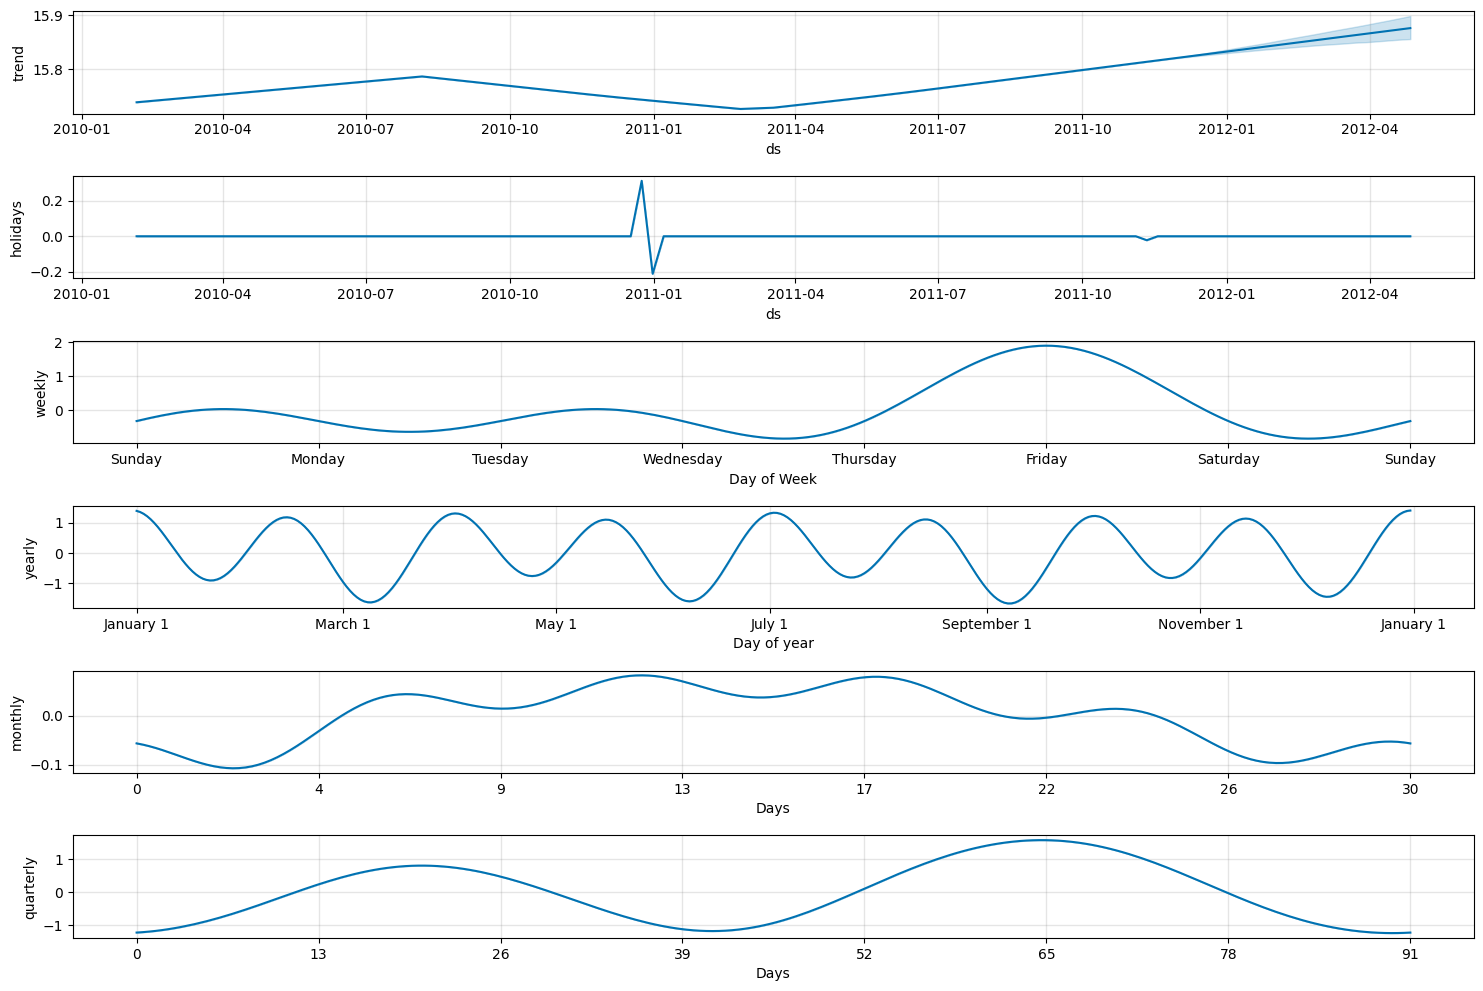

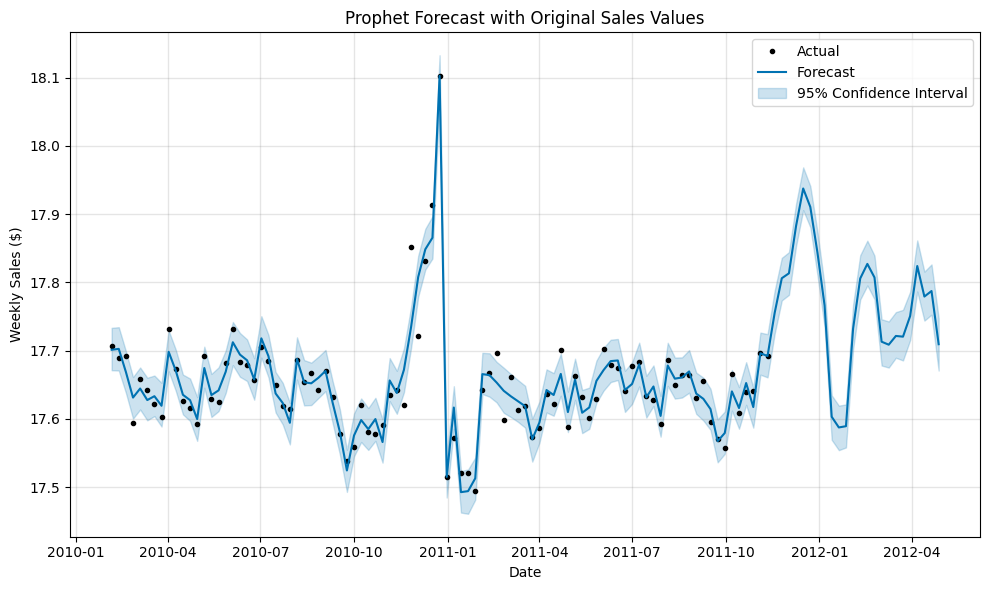

Prophet RMSE: 5559881.33
Prophet MAE: 4872086.97
Prophet R²: 0.3103


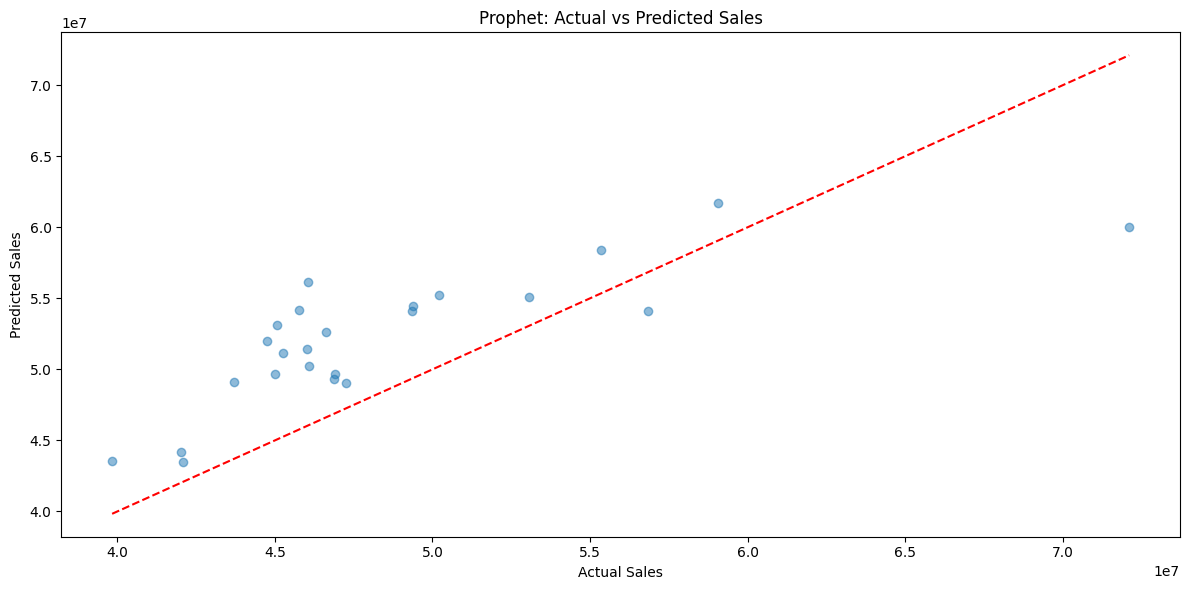

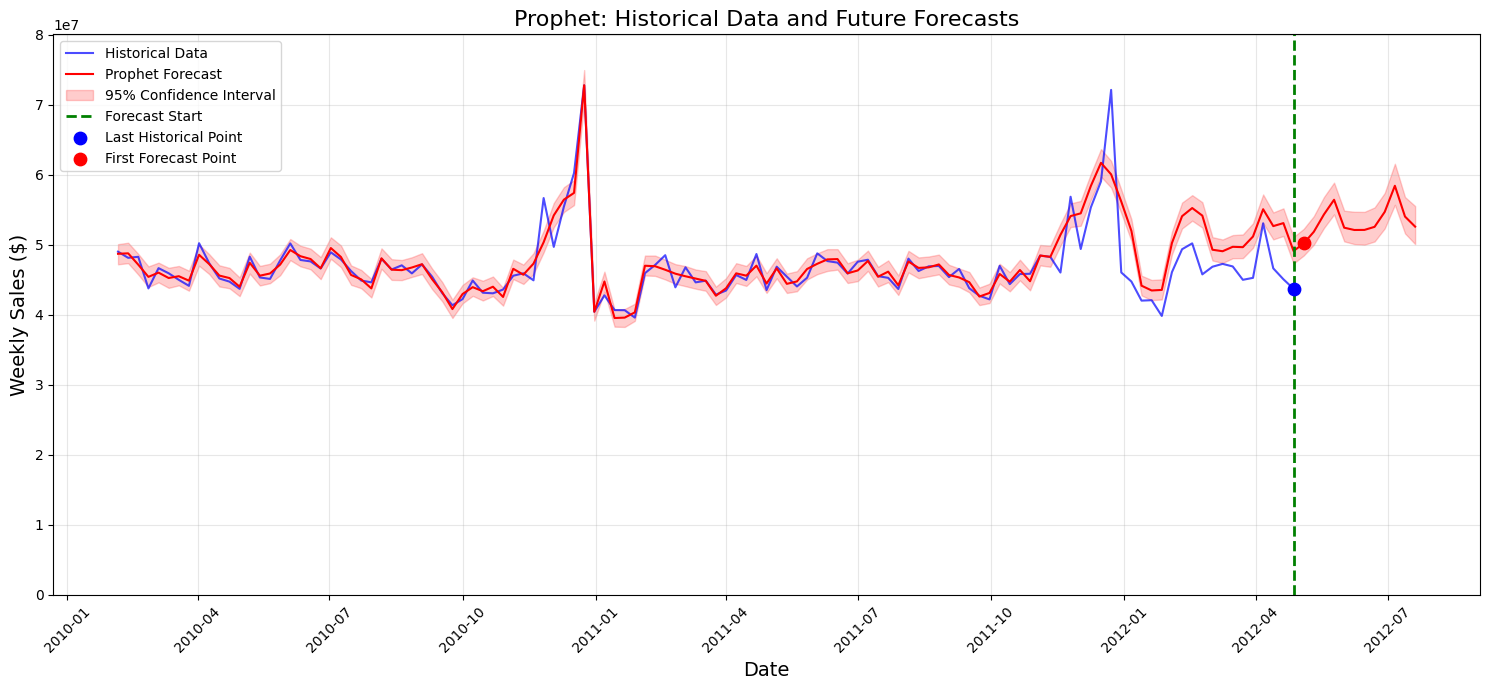


Future Sales Forecast (Next 12 weeks):
Week 1 (2012-05-04): $50186287.03
Week 2 (2012-05-11): $51844602.57
Week 3 (2012-05-18): $54323725.56
Week 4 (2012-05-25): $56422518.52
Week 5 (2012-06-01): $52434657.44
Week 6 (2012-06-08): $52106658.13
Week 7 (2012-06-15): $52118270.15
Week 8 (2012-06-22): $52558056.35
Week 9 (2012-06-29): $54694357.57
Week 10 (2012-07-06): $58416972.56
Week 11 (2012-07-13): $54021919.32
Week 12 (2012-07-20): $52584144.41


In [112]:
## Facebook Prophet Implementation - Fixed Version

# Install Prophet if not already installed
# !pip install prophet

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import boxcox, boxcox_normmax
from scipy.special import inv_boxcox

# Define selected_data from train DataFrame
selected_data = train.copy()
selected_data.index.name = "Date"

# Prepare data for Prophet
prophet_df = selected_data.reset_index()[['Date', 'Weekly_Sales']].rename(
    columns={'Date': 'ds', 'Weekly_Sales': 'y'}
)

print(f"Prophet data shape: {prophet_df.shape}")
prophet_df.head()

# Check for zero or negative values in the data
print(f"Min value: {prophet_df['y'].min()}")
if prophet_df['y'].min() <= 0:
    print("Warning: Data contains zero or negative values, using log transformation instead of Box-Cox")
    use_boxcox = False
else:
    use_boxcox = True

# Apply Box-Cox transformation to stabilize variance (if all values are positive)
if use_boxcox:
    prophet_df['y_orig'] = prophet_df['y'].copy()
    try:
        # Find optimal lambda parameter
        lambda_param = boxcox_normmax(prophet_df['y'])
        prophet_df['y'], _ = boxcox(prophet_df['y'], lmbda=lambda_param)
        print(f"Optimal Box-Cox lambda: {lambda_param:.4f}")
    except Exception as e:
        print(f"Box-Cox transformation failed: {e}")
        print("Falling back to log transformation (log1p)")
        prophet_df['y'] = np.log1p(prophet_df['y_orig'])
        use_boxcox = False
else:
    prophet_df['y_orig'] = prophet_df['y'].copy()
    # Use log transformation instead
    prophet_df['y'] = np.log1p(prophet_df['y'])
    print("Using log transformation (log1p)")

# Split into train and test sets using the same 80/20 ratio
train_size = int(len(prophet_df) * 0.8)
train_df = prophet_df[:train_size]
test_df = prophet_df[train_size:]

print(f"Training data: {train_df.shape}")
print(f"Testing data: {test_df.shape}")

# Create and fit Prophet model with improved hyperparameters for retail forecasting
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',  # Better for retail sales data
    changepoint_prior_scale=0.05,       # Controls flexibility of trend
    seasonality_prior_scale=1.0,       # Controls flexibility of seasonality
)

# Add US holidays
model.add_country_holidays(country_name='US')

# Add custom seasonalities for retail patterns
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model.add_seasonality(name='quarterly', period=91.25, fourier_order=5)

# Fit the model
model.fit(train_df)

# Make predictions on the test set - ensure we include test period exactly
# FIX: Generate future dates using the actual test dates for exact alignment
future = pd.DataFrame({'ds': prophet_df['ds'].values})
forecast = model.predict(future)

# Print sample dates to verify alignment
print("\nDate alignment check:")
print("First 3 test dates:", test_df['ds'].dt.date.iloc[:3].tolist())
print("Last 3 forecast dates matching test period:", 
      forecast['ds'].dt.date.iloc[train_size:train_size+3].tolist())

# Convert predictions back to original scale
if use_boxcox:
    forecast['yhat_orig'] = inv_boxcox(forecast['yhat'], lambda_param)
    forecast['yhat_lower_orig'] = inv_boxcox(forecast['yhat_lower'], lambda_param)
    forecast['yhat_upper_orig'] = inv_boxcox(forecast['yhat_upper'], lambda_param)
else:
    forecast['yhat_orig'] = np.expm1(forecast['yhat'])
    forecast['yhat_lower_orig'] = np.expm1(forecast['yhat_lower'])
    forecast['yhat_upper_orig'] = np.expm1(forecast['yhat_upper'])

# Visualize forecast components
fig1 = model.plot_components(forecast)
fig1.set_size_inches(15, 10)
plt.tight_layout()
plt.show()

# Plot predictions (using original scale)
fig2 = model.plot(forecast)
plt.title('Prophet Forecast with Original Sales Values')
plt.ylabel('Weekly Sales ($)')
plt.xlabel('Date')
plt.legend(['Actual', 'Forecast', '95% Confidence Interval'])
plt.tight_layout()
plt.show()

# Calculate metrics on test set
# FIX: Ensure exact date alignment by using test indices directly
test_indices = range(train_size, len(prophet_df))
test_forecast = forecast.iloc[test_indices].copy()
test_actuals = prophet_df.iloc[test_indices].copy()

# Create a clean dataframe with aligned predictions and actuals
comparison_df = pd.DataFrame({
    'ds': test_actuals['ds'],
    'actual': test_actuals['y_orig'],
    'predicted': test_forecast['yhat_orig']
})

# Now calculate metrics with properly aligned data
prophet_rmse = np.sqrt(mean_squared_error(comparison_df['actual'], comparison_df['predicted']))
prophet_mae = mean_absolute_error(comparison_df['actual'], comparison_df['predicted'])
prophet_r2 = r2_score(comparison_df['actual'], comparison_df['predicted'])

print(f"Prophet RMSE: {prophet_rmse:.2f}")
print(f"Prophet MAE: {prophet_mae:.2f}")
print(f"Prophet R²: {prophet_r2:.4f}")

# Plot actual vs predicted with fixed alignment
plt.figure(figsize=(12, 6))
plt.scatter(comparison_df['actual'], comparison_df['predicted'], alpha=0.5)
plt.plot([comparison_df['actual'].min(), comparison_df['actual'].max()], 
         [comparison_df['actual'].min(), comparison_df['actual'].max()], 
         'r--')
plt.title('Prophet: Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.tight_layout()
plt.show()

# Make future predictions beyond existing data
# FIX: Use a clear starting point for future predictions
# Get the weekday of the last date in the historical data
last_date = prophet_df['ds'].max()
weekday = last_date.weekday()  # Monday=0, Sunday=6

# Generate future dates that match the weekday of the last historical date
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=7),
    periods=12,
    freq=pd.offsets.Week(weekday=weekday)
)
future_df = pd.DataFrame({'ds': future_dates})

# Combine with history for a complete forecast
complete_future = pd.concat([
    pd.DataFrame({'ds': prophet_df['ds']}),
    future_df
])

# Make predictions
full_forecast = model.predict(complete_future)

# Convert to original scale
if use_boxcox:
    full_forecast['yhat_orig'] = inv_boxcox(full_forecast['yhat'], lambda_param)
    full_forecast['yhat_lower_orig'] = inv_boxcox(full_forecast['yhat_lower'], lambda_param)
    full_forecast['yhat_upper_orig'] = inv_boxcox(full_forecast['yhat_upper'], lambda_param)
else:
    full_forecast['yhat_orig'] = np.expm1(full_forecast['yhat'])
    full_forecast['yhat_lower_orig'] = np.expm1(full_forecast['yhat_lower'])
    full_forecast['yhat_upper_orig'] = np.expm1(full_forecast['yhat_upper'])

# Plot the full forecast including future predictions
plt.figure(figsize=(15, 7))

# Plot historical data
plt.plot(prophet_df['ds'], prophet_df['y_orig'], 'b-', 
         label='Historical Data', linewidth=1.5, alpha=0.7)

# Plot the entire forecast (both historical period and future)
plt.plot(full_forecast['ds'], full_forecast['yhat_orig'], 
         color='red', label='Prophet Forecast', linewidth=1.5)

# Fill confidence interval
plt.fill_between(full_forecast['ds'], 
                 full_forecast['yhat_lower_orig'], 
                 full_forecast['yhat_upper_orig'], 
                 color='red', alpha=0.2, label='95% Confidence Interval')

# Highlight the forecast boundary more clearly
plt.axvline(x=prophet_df['ds'].iloc[-1], color='green', 
            linestyle='--', label='Forecast Start', linewidth=2)

# Add markers at the transition point to make it clear
plt.scatter([prophet_df['ds'].iloc[-1]], [prophet_df['y_orig'].iloc[-1]], 
            color='blue', s=80, zorder=5, label='Last Historical Point')
plt.scatter([future_dates[0]], [full_forecast['yhat_orig'].iloc[len(prophet_df)]], 
            color='red', s=80, zorder=5, label='First Forecast Point')

# Ensure y-axis starts at zero and has appropriate scaling
plt.ylim(bottom=0)
y_max = max(prophet_df['y_orig'].max(), full_forecast['yhat_orig'].max()) * 1.1
plt.ylim(top=y_max)

# Improve formatting
plt.title('Prophet: Historical Data and Future Forecasts', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Weekly Sales ($)', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Print future forecasts - only for the actual future predictions
future_only = full_forecast.iloc[len(prophet_df):].reset_index(drop=True)
print("\nFuture Sales Forecast (Next 12 weeks):")
for i, (date, forecast) in enumerate(zip(future_only['ds'], future_only['yhat_orig'])):
    print(f"Week {i+1} ({date.date()}): ${forecast:.2f}")



C:\Users\shazi\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


                 RMSE           MAE            R2
XGBoost  1.885415e+04  1.883884e+04 -7.212704e+06
SARIMA   1.898358e+06  1.409357e+06  0.000000e+00
LSTM     4.075097e+03  3.770319e+03 -1.152409e+00
Prophet  5.559881e+06  4.872087e+06  3.102844e-01


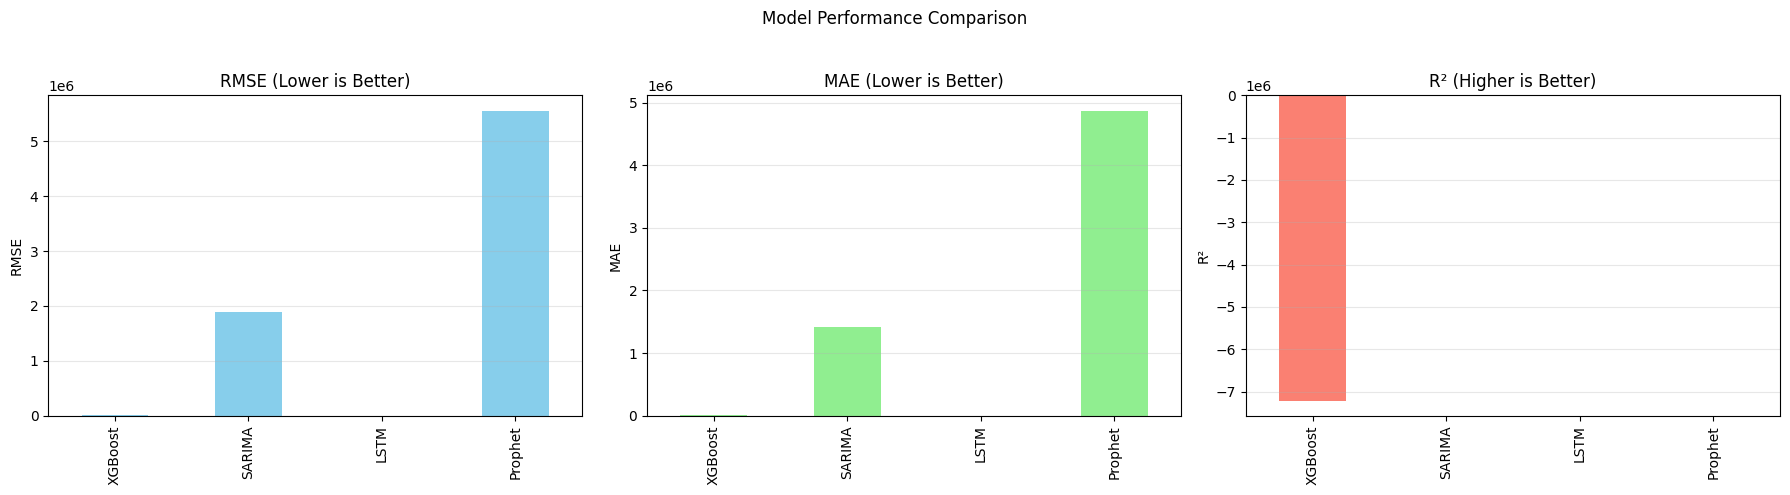

In [124]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure y_test and y_pred are 1D arrays of the same length
y_test_xgb = np.array(y_test).ravel()
y_pred_xgb = np.array(y_pred).ravel()
min_len = min(len(y_test_xgb), len(y_pred_xgb))
y_test_xgb = y_test_xgb[:min_len]
y_pred_xgb = y_pred_xgb[:min_len]

# Prepare metrics for all models (replace test_rmse, test_mae, test_r2 with your LSTM metrics)
models = ['XGBoost', 'SARIMA', 'LSTM', 'Prophet']
metrics_df = pd.DataFrame({
    'RMSE': [
        np.sqrt(metrics.mean_squared_error(y_test_xgb, y_pred_xgb)),  # XGBoost
        np.sqrt(np.mean(residuals**2)),                              # SARIMA
        test_rmse,                                                   # LSTM
        prophet_rmse                                                 # Prophet
    ],
    'MAE': [
        metrics.mean_absolute_error(y_test_xgb, y_pred_xgb),         # XGBoost
        np.mean(np.abs(residuals)),                                  # SARIMA
        test_mae,                                                    # LSTM
        prophet_mae                                                  # Prophet
    ],
    'R2': [
        metrics.explained_variance_score(y_test_xgb, y_pred_xgb),    # XGBoost
        1 - (np.sum(residuals**2) / np.sum((test.Weekly_Sales - test.Weekly_Sales.mean())**2)),  # SARIMA
        test_r2,                                                     # LSTM
        prophet_r2                                                   # Prophet
    ]
}, index=models)

# Convert all columns to numeric and fill NaNs with 0 for plotting
metrics_df = metrics_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Optional: print for debugging
print(metrics_df)

# Plot RMSE, MAE, and R2 for all models
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

metrics_df['RMSE'].plot(kind='bar', ax=axs[0], color='skyblue')
axs[0].set_ylabel('RMSE')
axs[0].set_title('RMSE (Lower is Better)')
axs[0].grid(axis='y', alpha=0.3)

metrics_df['MAE'].plot(kind='bar', ax=axs[1], color='lightgreen')
axs[1].set_ylabel('MAE')
axs[1].set_title('MAE (Lower is Better)')
axs[1].grid(axis='y', alpha=0.3)

metrics_df['R2'].plot(kind='bar', ax=axs[2], color='salmon')
axs[2].set_ylabel('R²')
axs[2].set_title('R² (Higher is Better)')
axs[2].grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()